# 大数定律与中心极限定理

> 概率论的两大支柱：一个告诉你「平均值一定会稳定下来」，另一个告诉你「波动究竟长什么样」。

## 这两条定理分别在回答什么问题？

| 问题 | 回答者 | 数学语言 |
|---|---|---|
| 样本均值 $\bar X_n$ 会不会收敛？收敛到哪里？ | **大数定律 (LLN)** | $\bar X_n \to \mu$ |
| 收敛有多快？误差 $\bar X_n-\mu$ 的分布长什么样？ | **中心极限定理 (CLT)** | $\sqrt{n}(\bar X_n-\mu) \xrightarrow{\ d\ } N(0,\sigma^2)$ |

一句话概括分工：

- **LLN 是一阶结论**：$n\to\infty$ 时，误差本身趋于 $0$。
- **CLT 是二阶结论**：把误差放大 $\sqrt{n}$ 倍之后，它既不爆炸也不消失，而是稳定成一个**正态分布**。

> 很多人学完这两条定理后仍觉得它们是「天上掉下来的结论」。本笔记的目标是让你看到：
> **它们都只是同一个事实（$\mathrm{Var}(\bar X_n)=\sigma^2/n$）的两个推论**，而正态分布之所以出现，是因为它是「独立随机变量相加」这个操作的不动点。

## 学习路线

```
第 0 章  前置速查        —— 随机变量 / 期望方差 / 特征函数 / 四种收敛 / 两个不等式
              ↓
第 1 章  大数定律 LLN    —— 直觉 → WLLN 证明 → SLLN 证明 → 反例 → 收敛速率实验
              ↓
第 2 章  中心极限定理 CLT —— 直觉 → 特征函数证明 → 为什么是正态 → 推广 → 实验
              ↓
第 3 章  两者的关系      —— 一阶 vs 二阶；同一个 σ²/n 的两个侧面
              ↓
第 4 章  深度学习中的意义 —— 蒙特卡洛、SGD 梯度噪声、批量大小、参数初始化
              ↓
第 5 章  常见误区与练习
```

**阅读建议**：所有代码单元都可以直接运行，改改参数（尤其是 $n$、分布类型、重复次数）比只看图收获大得多。

---
# 第 0 章　前置速查

这一章把后面反复用到的工具一次性摆出来，方便随时回查。

## 0.1 随机变量与分布

随机变量 $X$ 是从样本空间到实数的可测映射。它的全部信息由**分布函数**刻画：

$$F_X(x)=P(X\le x),\qquad x\in\mathbb R$$

- 离散型：$p_k=P(X=x_k)$，$\sum_k p_k=1$
- 连续型：$f_X(x)=F_X'(x)\ge 0$，$\int_{-\infty}^{\infty}f_X(x)\,dx=1$

## 0.2 期望、方差、矩

$$\mathbb E[X]=\int_{-\infty}^{\infty}x\,f_X(x)\,dx,\qquad
\operatorname{Var}(X)=\mathbb E\big[(X-\mu)^2\big]=\mathbb E[X^2]-\mu^2$$

两条**后面反复用到**的性质：

**（1）期望的线性性**（不要求独立！）

$$\mathbb E[aX+bY]=a\,\mathbb E[X]+b\,\mathbb E[Y]$$

**（2）方差的可加性**（要求不相关；独立是充分条件）

$$X\perp Y\ \Longrightarrow\ \operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)$$

于是对 i.i.d.（独立同分布）序列 $X_1,\dots,X_n$，设 $\mathbb E[X_i]=\mu,\ \operatorname{Var}(X_i)=\sigma^2$：

$$\boxed{\ \mathbb E[\bar X_n]=\mu,\qquad \operatorname{Var}(\bar X_n)=\frac{\sigma^2}{n},\qquad
\mathrm{SE}(\bar X_n)=\frac{\sigma}{\sqrt n}\ }$$

其中 $\bar X_n=\frac1n\sum_{i=1}^n X_i$。

> **这个 $\sigma/\sqrt n$ 是全章的发动机。**
> 让 $n\to\infty$，它趋于 $0$ —— 这就是 **LLN**。
> 把它乘回去 $\sqrt n$，尺度变成常数 $\sigma$ —— 这就是 **CLT**。

## 0.3 矩母函数与特征函数

$$\text{矩母函数：}\ M_X(t)=\mathbb E[e^{tX}]\qquad\qquad
\text{特征函数：}\ \varphi_X(t)=\mathbb E[e^{itX}]=\int_{-\infty}^{\infty}e^{itx}f_X(x)\,dx$$

**为什么 CLT 的证明一定要用特征函数？** 因为它把**卷积变成乘积**：

$$X\perp Y\ \Longrightarrow\ \varphi_{X+Y}(t)=\varphi_X(t)\,\varphi_Y(t)$$

而「独立随机变量求和」在分布层面就是「分布的卷积」。卷积直接算极其痛苦，做一次傅里叶变换（即取特征函数）就变成简单的乘法 —— 这是 CLT 证明的全部秘密。

特征函数相比矩母函数的两个优势：

1. **总是存在**：因为 $|e^{itx}|=1$，积分一定绝对收敛，而矩母函数可能在某处发散（如柯西分布）。
2. **唯一决定分布**：$\varphi_X=\varphi_Y \iff F_X=F_Y$（Lévy 连续性定理，也是 CLT 最后一步的依据）。

## 0.4 四种收敛模式（必须分清）

设 $X_1,X_2,\dots$ 与 $X$ 是随机变量。

| 名称 | 记号 | 定义 | 直觉 |
|---|---|---|---|
| **依概率收敛** | $X_n\xrightarrow{P}X$ | $\forall\varepsilon>0,\ P(|X_n-X|\ge\varepsilon)\to 0$ | 偏差大的**概率**趋于 0 |
| **几乎必然收敛** | $X_n\xrightarrow{a.s.}X$ | $P\big(\lim_{n\to\infty}X_n=X\big)=1$ | 除零概率集外，**每条轨道**都收敛 |
| **$L^p$ 收敛** | $X_n\xrightarrow{L^p}X$ | $\mathbb E|X_n-X|^p\to 0$ | 误差的**期望**趋于 0 |
| **依分布收敛** | $X_n\xrightarrow{d}X$ | $F_{X_n}(x)\to F_X(x)$ 于 $F_X$ 的连续点 | 分布形状趋同，**不关心同一概率空间** |

包含关系（箭头方向为「更强」）：

$$L^p\ \Longrightarrow\ \xrightarrow{P}\ \Longrightarrow\ \xrightarrow{d},\qquad
\xrightarrow{a.s.}\ \Longrightarrow\ \xrightarrow{P}\ \Longrightarrow\ \xrightarrow{d}$$

注意：$\xrightarrow{a.s.}$ 与 $\xrightarrow{L^p}$ 之间**没有**包含关系；而 $\xrightarrow{d}$ 是最弱的，它甚至不要求所有变量定义在同一个概率空间上 —— 这正是 CLT 的结论形式。

## 0.5 两个不等式（LLN 证明的引擎）

**马尔可夫不等式（Markov）**：设 $X\ge 0$，$a>0$，则

$$P(X\ge a)\le \frac{\mathbb E[X]}{a}$$

*证明*：$X\ge a\,\mathbf 1_{\{X\ge a\}}$ 逐点成立，两边取期望即得。$\blacksquare$

**切比雪夫不等式（Chebyshev）**：设 $\mathbb E[X]=\mu,\ \operatorname{Var}(X)=\sigma^2$，则对任意 $\varepsilon>0$

$$\boxed{\ P(|X-\mu|\ge\varepsilon)\ \le\ \frac{\sigma^2}{\varepsilon^2}\ }$$

*证明*：对非负随机变量 $Y=(X-\mu)^2$ 用马尔可夫不等式（取 $a=\varepsilon^2$）：

$$P\big((X-\mu)^2\ge\varepsilon^2\big)\le\frac{\mathbb E[(X-\mu)^2]}{\varepsilon^2}=\frac{\sigma^2}{\varepsilon^2}.\qquad\blacksquare$$

切比雪夫不等式虽然粗糙，但它是**普适**的 —— 只要知道方差就能给出界，不依赖任何分布假设。这就是它能用来证明「对任意分布都成立的 LLN」的原因。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from statistics import NormalDist

rng = np.random.default_rng(42)

# ---- 中文字体设置（Windows / macOS 常见的几种都试一遍）----
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Noto Sans CJK SC', 'Arial Unicode MS']:
    if _name in _installed:
        plt.rcParams['font.sans-serif'] = [_name]
        break
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ND = NormalDist()          # 标准正态分布，提供 .pdf/.cdf/.inv_cdf，替代 scipy
print('numpy', np.__version__)
print('中文字体:', plt.rcParams['font.sans-serif'][0])

numpy 2.4.4
中文字体: Microsoft YaHei


## 0.6 把上面的公式跑一遍

理论公式容易「看着懂、用着虚」。下面用三个小实验把 0.2 节的三个核心结论钉死：

1. $\operatorname{Var}(\bar X_n)=\sigma^2/n$ 是真的吗？
2. 特征函数真的把卷积变成了乘积吗？
3. 切比雪夫不等式给出的界到底有多松？

In [2]:
# ---- 实验 1：验证 Var(X_bar) = sigma^2 / n ----
lam, n, reps = 3.0, 100, 200_000          # 泊松分布: mu = var = lambda

samples = rng.poisson(lam, size=(reps, n))   # 200000 次独立重复实验，每次抽 n 个
means = samples.mean(axis=1)                 # 每次实验得到一个 X_bar

se_theory = np.sqrt(lam / n)
print(f'理论: E[X]={lam:.4f}  Var(X)={lam:.4f}  SE(X_bar)=sqrt(lam/n)={se_theory:.6f}')
print(f'实测: mean(X_bar)={means.mean():.4f}  std(X_bar)={means.std(ddof=1):.6f}')
print(f'实测标准差 / 理论SE = {means.std(ddof=1)/se_theory:.4f}   (应接近 1)')

# 顺便看看 n 变化时 SE 的衰减规律
for n_ in [10, 100, 1000, 5000]:
    m = rng.poisson(lam, size=(5000, n_)).mean(axis=1)
    print(f'  n={n_:>6d}  实测 std={m.std(ddof=1):.5f}   理论 σ/√n={np.sqrt(lam/n_):.5f}')

理论: E[X]=3.0000  Var(X)=3.0000  SE(X_bar)=sqrt(lam/n)=0.173205
实测: mean(X_bar)=2.9998  std(X_bar)=0.172836
实测标准差 / 理论SE = 0.9979   (应接近 1)
  n=    10  实测 std=0.54852   理论 σ/√n=0.54772
  n=   100  实测 std=0.17324   理论 σ/√n=0.17321
  n=  1000  实测 std=0.05597   理论 σ/√n=0.05477


  n=  5000  实测 std=0.02450   理论 σ/√n=0.02449


经验 φ_S(2.0) = -0.1194+0.1599j
乘积 φ_X·φ_Y   = -0.1200+0.1600j


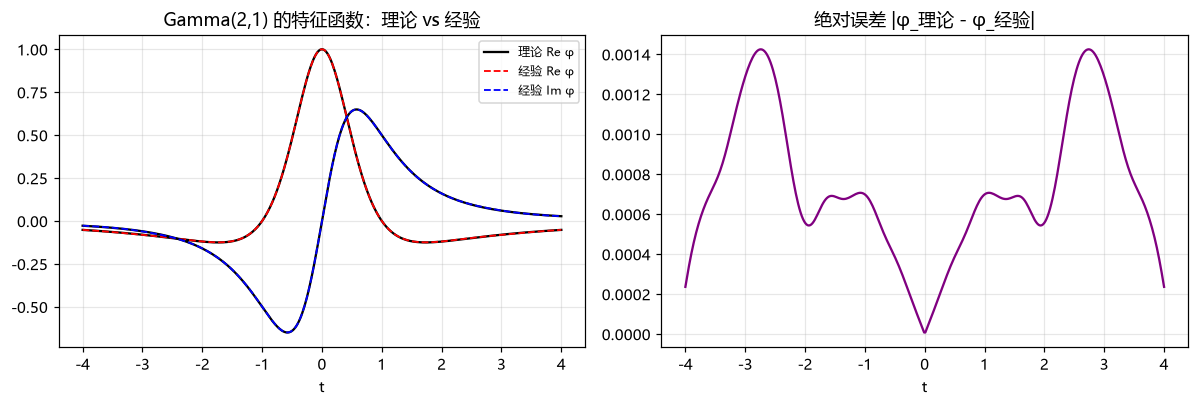

In [3]:
# ---- 实验 2：特征函数把卷积变成乘积 ----
# 取 X, Y ~ Exp(1) 独立，则 S = X+Y ~ Gamma(2,1)，其特征函数为 1/(1-it)^2
a = rng.exponential(1.0, 500_000)
b = rng.exponential(1.0, 500_000)
s = a + b

t0 = 2.0
phi_emp = np.mean(np.exp(1j * t0 * s))          # 直接对 S 取样本均值
phi_mul = (1 / (1 - 1j * t0)) * (1 / (1 - 1j * t0))   # 特征函数相乘
print(f'经验 φ_S({t0}) = {phi_emp:.4f}')
print(f'乘积 φ_X·φ_Y   = {phi_mul:.4f}')

# 画出来看看：特征函数乘积 vs 经验特征函数
t = np.linspace(-4, 4, 400)
phi_theory = 1 / (1 - 1j * t) ** 2
phi_hat = np.array([np.mean(np.exp(1j * ti * s)) for ti in t])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t, phi_theory.real, 'k-', label='理论 Re φ')
axes[0].plot(t, phi_hat.real, 'r--', lw=1.2, label='经验 Re φ')
axes[0].plot(t, phi_theory.imag, 'k-')
axes[0].plot(t, phi_hat.imag, 'b--', lw=1.2, label='经验 Im φ')
axes[0].set_title('Gamma(2,1) 的特征函数：理论 vs 经验')
axes[0].set_xlabel('t'); axes[0].legend(fontsize=8)

axes[1].plot(t, np.abs(phi_theory - phi_hat), 'purple')
axes[1].set_title('绝对误差 |φ_理论 - φ_经验|')
axes[1].set_xlabel('t')
plt.tight_layout(); plt.show()

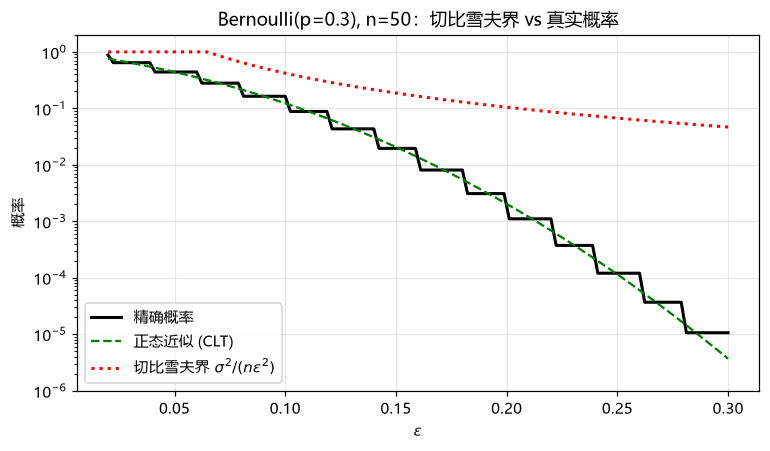

结论：切比雪夫界是"上界"，量级正确（都是关于 ε 的二次衰减），
      但常数很保守；而 CLT 给出的正态近似几乎与精确值重合。


In [4]:
# ---- 实验 3：切比雪夫不等式到底有多松？----
# X ~ Bernoulli(p=0.3), X_bar_n 的精确尾概率 vs 切比雪夫界
from math import comb

p, n = 0.3, 50
mu, var = p, p * (1 - p)
se = np.sqrt(var / n)

# 精确计算 P(|X_bar - mu| >= eps) = P(|S_n - np| >= n*eps)，S_n ~ Binomial(n, p)
eps_grid = np.linspace(0.02, 0.30, 120)
exact = np.array([
    sum(comb(n, k) * p**k * (1 - p)**(n - k) for k in range(n + 1) if abs(k - n * p) >= n * e)
    for e in eps_grid
])
cheb = np.minimum(var / (n * eps_grid**2), 1.0)   # P(|X_bar-mu|>=e) <= var/(n e^2)

# 用正态近似做参照（后面 CLT 会解释为什么可以这么算）
normal_approx = np.array([2 * (1 - ND.cdf(e / se)) for e in eps_grid])

plt.figure(figsize=(8, 4.2))
plt.plot(eps_grid, exact, 'k-', lw=2, label='精确概率')
plt.plot(eps_grid, normal_approx, 'g--', label='正态近似 (CLT)')
plt.plot(eps_grid, cheb, 'r:', lw=2, label=r'切比雪夫界 $\sigma^2/(n\varepsilon^2)$')
plt.yscale('log'); plt.ylim(1e-6, 2)
plt.xlabel(r'$\varepsilon$'); plt.ylabel('概率')
plt.title(f'Bernoulli(p={p}), n={n}：切比雪夫界 vs 真实概率')
plt.legend(); plt.show()

print('结论：切比雪夫界是"上界"，量级正确（都是关于 ε 的二次衰减），')
print('      但常数很保守；而 CLT 给出的正态近似几乎与精确值重合。')

---
# 第 1 章　大数定律（Law of Large Numbers）

## 1.1 它到底在说什么？

**一句话**：当你重复做同一个随机实验足够多次，样本均值会稳定到理论期望附近。

$$
\bar X_n=\frac{X_1+X_2+\cdots+X_n}{n}\ \xrightarrow[\ n\to\infty\ ]{}\ \mu=\mathbb E[X]
$$

这里的「收敛」有三种强弱不同的含义，对应三种大数定律：

| 名称 | 条件 | 结论 | 提出者 |
|---|---|---|---|
| **弱大数定律 WLLN** | i.i.d.，$\mathbb E\lvert X\rvert<\infty$ | $\bar X_n\xrightarrow{P}\mu$ | Khinchin (1929) |
| **强大数定律 SLLN** | i.i.d.，$\mathbb E\lvert X\rvert<\infty$ | $\bar X_n\xrightarrow{a.s.}\mu$ | Kolmogorov (1930) |
| **伯努利大数定律** | $X_i\sim\mathrm{Bernoulli}(p)$ | 频率 $\xrightarrow{P}p$ | Bernoulli (1713) |

## 1.2 直觉：为什么平均值一定会稳定？

看方差就够了。由 0.2 节的结论：

$$\operatorname{Var}(\bar X_n)=\frac{\sigma^2}{n}\ \xrightarrow{n\to\infty}\ 0$$

**均值不动（$\mathbb E[\bar X_n]=\mu$），方差趋于 0** —— 这意味着 $\bar X_n$ 这个随机变量被挤压成了一个「不随机的常数」$\mu$。

打个比方：$\bar X_n$ 像一团不断收缩的云，中心始终钉在 $\mu$，但体积以 $1/\sqrt n$ 的速度缩小。当 $n\to\infty$，这团云塌缩成一个点。

> **关键洞察**：LLN 的本质**不是**「随机性消失了」，而是「**平均**这个操作把随机性以 $1/n$ 的速率压制掉了」。
> 单个 $X_i$ 的方差是 $\sigma^2$，$n$ 个独立方差相加得 $n\sigma^2$，再除以 $n^2$ 得 $\sigma^2/n$ —— 分子线性增长，分母平方增长，这就是 $1/n$ 的来源。

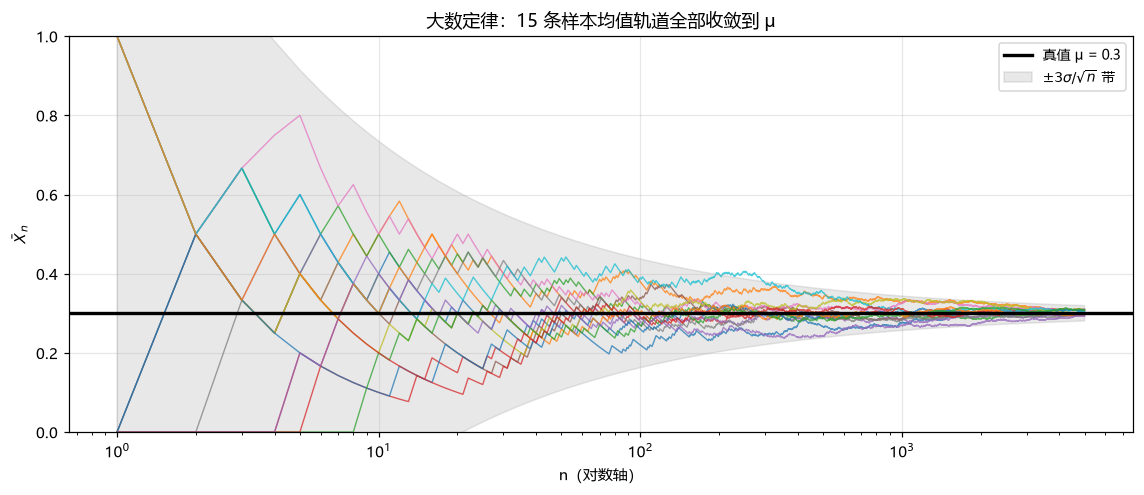

观察两个现象：
  1) 所有轨道最终都挤向 μ = 0.3；
  2) 收敛带宽度 ∝ 1/√n，但轨道在带内是"游走"的，不是单调逼近。
     —— 这正是 CLT 要刻画的：涨落的形状。


In [5]:
# ---- LLN 的第一张图：多条样本均值轨道 ----
p, N, K = 0.3, 5000, 15          # 伯努利参数、最大样本数、轨道条数
paths = rng.random((K, N)) < p
running = np.cumsum(paths, axis=1) / np.arange(1, N + 1)

ns = np.arange(1, N + 1)
envelope = 3 * np.sqrt(p * (1 - p) / ns)      # ±3σ/√n 收敛带

plt.figure(figsize=(10.5, 4.6))
for k in range(K):
    plt.plot(ns, running[k], lw=0.9, alpha=0.75)
plt.axhline(p, color='k', lw=2.2, label=f'真值 μ = {p}')
plt.fill_between(ns, p - envelope, p + envelope, color='gray', alpha=0.18,
                 label=r'$\pm 3\sigma/\sqrt{n}$ 带')
plt.xscale('log')
plt.ylim(0, 1)
plt.xlabel('n（对数轴）'); plt.ylabel(r'$\bar X_n$')
plt.title('大数定律：15 条样本均值轨道全部收敛到 μ')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print('观察两个现象：')
print('  1) 所有轨道最终都挤向 μ = 0.3；')
print('  2) 收敛带宽度 ∝ 1/√n，但轨道在带内是"游走"的，不是单调逼近。')
print('     —— 这正是 CLT 要刻画的：涨落的形状。')

## 1.3 弱大数定律（WLLN）与它的证明

### 定理（Khinchin，i.i.d. 情形）

设 $X_1,X_2,\dots$ 独立同分布，$\mathbb E[X_1]=\mu$ 存在（**只要求一阶矩有限**），则

$$\bar X_n=\frac1n\sum_{i=1}^n X_i\ \xrightarrow{\ P\ }\ \mu,\qquad
\text{即}\quad \forall\varepsilon>0:\ \lim_{n\to\infty}P\big(|\bar X_n-\mu|\ge\varepsilon\big)=0$$

### 证明（先做方差有限的情形）

**Step 1.** 计算 $\bar X_n$ 的均值与方差。

$$\mathbb E[\bar X_n]=\frac1n\sum_{i=1}^n\mathbb E[X_i]=\frac{n\mu}{n}=\mu$$

$$\operatorname{Var}(\bar X_n)\overset{\text{独立}}{=}\frac{1}{n^2}\sum_{i=1}^n\operatorname{Var}(X_i)=\frac{n\sigma^2}{n^2}=\frac{\sigma^2}{n}$$

**Step 2.** 对 $\bar X_n$ 应用切比雪夫不等式（取 $\varepsilon$ 固定）：

$$P\big(|\bar X_n-\mu|\ge\varepsilon\big)\ \le\ \frac{\operatorname{Var}(\bar X_n)}{\varepsilon^2}\ =\ \frac{\sigma^2}{n\,\varepsilon^2}$$

**Step 3.** 令 $n\to\infty$。右端对固定的 $\varepsilon>0$ 趋于 $0$，由夹逼得

$$\lim_{n\to\infty}P\big(|\bar X_n-\mu|\ge\varepsilon\big)=0.\qquad\blacksquare$$

### 如果方差不存在怎么办？（截断法思想）

上面的证明用到了 $\sigma^2<\infty$。Khinchin 的贡献正是**去掉了这个条件**。核心技巧叫**截断（truncation）**：

把 $X_i$ 拆成「有界部分」和「尾部」：

$$X_i=\underbrace{X_i\mathbf 1_{\{|X_i|\le M\}}}_{=:Y_i\ (\text{有界，故方差有限})}+\underbrace{X_i\mathbf 1_{\{|X_i|>M\}}}_{=:Z_i\ (\text{尾部})}$$

思路是三步：

1. 对固定的 $M$，$Y_i$ 有界 $\Rightarrow$ 方差有限 $\Rightarrow$ 由上面已证的结论，$\bar Y_n\xrightarrow{P}\mathbb E[Y_1]$；
2. $\mathbb E[Y_1]\to\mu$ 当 $M\to\infty$（由 $\mathbb E|X|<\infty$ 和控制收敛定理）；
3. 尾部贡献 $P(Z_i\ne 0)=P(|X_i|>M)$ 可以随 $M$ 任意小，且 $\bar Z_n$ 中非零项的比例依概率很小。

把三块拼起来即得结论。**注意 $\mathbb E|X|<\infty$ 是不可省的**（见 1.6 节的柯西反例）。

> **为什么叫「弱」？** 因为它只断言「对每个固定的 $n$，偏差大的概率小」，而**允许**在 $n$ 增大过程中，偏差偶尔反复变大。也就是说：**偏差小的概率 → 1，但不保证每条轨道都收敛**。

## 1.4 强大数定律（SLLN）

### 定理（Kolmogorov）

设 $X_1,X_2,\dots$ 独立同分布，$\mathbb E|X_1|<\infty$，$\mathbb E[X_1]=\mu$，则

$$\bar X_n\ \xrightarrow{\ a.s.\ }\ \mu,\qquad
\text{即}\quad P\Big(\Big\{\omega:\lim_{n\to\infty}\bar X_n(\omega)=\mu\Big\}\Big)=1$$

### 强弱差别到底在哪？（这是最容易被忽略的一点）

把「收敛」写成一个集合，差别立刻清晰：

$$\underbrace{\Big\{\omega:\lim_{n\to\infty}\bar X_n(\omega)=\mu\Big\}}_{\text{SLLN 断言它的概率为 1}}
\qquad\text{vs}\qquad
\underbrace{\forall\varepsilon>0:\ \lim_{n\to\infty}P\big(|\bar X_n-\mu|\ge\varepsilon\big)=0}_{\text{WLLN 断言每个 n 的尾概率趋于 0}}$$

- **WLLN**：先固定 $n$ 看概率，再让 $n\to\infty$。可以理解为「逐点的」。
- **SLLN**：先固定一条轨道 $\omega$（一整个无穷序列），看这条轨道作为数列是否收敛。要求**同时**对所有 $n$ 成立。

用「游走」比喻：WLLN 说「任意时刻 $n$，你离家的距离大概率很近」；SLLN 说「你离家越来越远这种事的概率是 0，最终你必回家，而且不再离开」。

**WLLN 允许的情形**：偏差 $\ge\varepsilon$ 的事件会发生无穷多次，但发生的**时间点**越来越稀疏，使得任意时刻的瞬时概率仍趋于 0。SLLN 用 **Borel–Cantelli 引理**排除了这种情况。

### 一个直观的证明（四阶矩情形）

为了让证明不依赖高级工具，这里假设 $\mathbb E[X^4]<\infty$，并令 $\mu=0,\ \sigma^2=\mathbb E[X^2]$。

**Step 1.** 展开四阶矩。记 $S_n=\sum_{i=1}^n X_i$，则

$$\mathbb E[S_n^4]=\sum_{i,j,k,l}\mathbb E[X_iX_jX_kX_l]$$

由于 $X$ 独立且均值为 $0$，任何含「一次幂下标」的项期望为 $0$。只有两类项存活：

- 四个下标全同：$n$ 项，每项 $\mathbb E[X^4]$；
- 两两配对：$\binom{4}{2}\cdot\frac{n(n-1)}{2}=3n(n-1)$ 项，每项 $\mathbb E[X^2]^2=\sigma^4$。

所以

$$\mathbb E[S_n^4]=n\,\mathbb E[X^4]+3n(n-1)\sigma^4\ \le\ C\,n^2$$

**Step 2.** 对 $\bar X_n=S_n/n$ 用马尔可夫不等式（$X^4\ge0$）：

$$P\big(|\bar X_n|\ge\varepsilon\big)=P\big(S_n^4\ge n^4\varepsilon^4\big)\le\frac{\mathbb E[S_n^4]}{n^4\varepsilon^4}\le\frac{C}{n^2\varepsilon^4}$$

**Step 3.** 右端关于 $n$ **可求和**：

$$\sum_{n=1}^\infty P\big(|\bar X_n|\ge\varepsilon\big)\le\frac{C}{\varepsilon^4}\sum_{n=1}^\infty\frac{1}{n^2}<\infty$$

由 **Borel–Cantelli 引理**（若 $\sum_n P(A_n)<\infty$，则 $P(A_n\ \text{i.o.})=0$）：

$$P\big(|\bar X_n|\ge\varepsilon\ \text{无穷多次}\big)=0$$

即：对几乎必然的 $\omega$，存在 $N(\omega)$ 使得 $n>N$ 时 $|\bar X_n|<\varepsilon$。对 $\varepsilon=1/k$ 取可数个交，得到

$$P\Big(\lim_{n\to\infty}\bar X_n=0\Big)=1.\qquad\blacksquare$$

> **注意 Step 3 的关键**：概率衰减速度从切比雪夫的 $1/n$（不可求和，只给 WLLN）变成了 $1/n^2$（可求和，给 SLLN）。
> **更快的衰减 + Borel–Cantelli = 更强的收敛**。这就是「强」的数学来源。

## 1.5 三种收敛在 LLN 语境下的对照

| | WLLN | SLLN |
|---|---|---|
| 结论 | $\bar X_n\xrightarrow{P}\mu$ | $\bar X_n\xrightarrow{a.s.}\mu$ |
| 证明工具 | 切比雪夫不等式 | Borel–Cantelli + 可求和界 |
| 需要的概率衰减 | $o(1)$ | 关于 $n$ **可求和** |
| 允许「反复偏离」吗 | 允许（只要越来越稀疏） | 不允许 |
| 反例 | —— | 存在满足 WLLN 但不满足 SLLN 的序列 |
| 强度 | 弱 | 强（$\xrightarrow{a.s.}\Rightarrow\xrightarrow{P}$，反之不成立） |

**为什么教材先讲 WLLN？** 因为它证明简单（一个不等式就够），且结论已经够用（例如用频率估计概率、用蒙特卡洛估计积分）。SLLN 的价值在于它刻画了「整条轨道」的行为，是鞅论、遍历理论、统计一致性理论的基础。

## 1.6 反例：柯西分布为什么打破了大数定律？

标准柯西分布 $X\sim\mathrm{Cauchy}(0,1)$ 的密度是

$$f(x)=\frac{1}{\pi(1+x^2)},\qquad x\in\mathbb R$$

它看起来和正态分布很像（都是钟形、对称），但有一个致命区别：**尾部太厚**。

$$P(|X|>x)=\frac{2}{\pi}\int_x^\infty\frac{dt}{1+t^2}\sim\frac{2}{\pi x}\qquad(x\to\infty)$$

也就是**尾概率只按 $1/x$ 衰减**（正态是按 $e^{-x^2/2}$ 衰减）。后果是：

$$\mathbb E|X|=\frac{2}{\pi}\int_0^\infty\frac{x}{1+x^2}\,dx=\infty$$

**一阶矩不存在**，LLN 的条件被破坏。

### 更惊人的事实：柯西分布是「平均值的不动点」

设 $X_1,X_2$ 独立同服从 $\mathrm{Cauchy}(0,1)$。用特征函数可以证明（$\varphi_X(t)=e^{-|t|}$）：

$$\varphi_{X_1+X_2}(t)=e^{-|t|}\cdot e^{-|t|}=e^{-2|t|}\ \Longrightarrow\ X_1+X_2\sim\mathrm{Cauchy}(0,2)$$

于是 $\dfrac{X_1+X_2}{2}\sim\mathrm{Cauchy}(0,1)$ —— **平均之后分布完全没变**！推广可得

$$\bar X_n\sim\mathrm{Cauchy}(0,1)\qquad\text{对任意 } n \text{ 成立}$$

也就是说：**取平均完全无助于降低不确定性**。$\bar X_n$ 与单个 $X_1$ 的分布一模一样，永远不可能收敛到常数。

> 这解释了为什么 LLN 的条件 $\mathbb E|X|<\infty$ 是**本质的**，而不是证明技巧的副产品。
> 顺便：柯西分布的矩母函数 $\mathbb E[e^{tX}]$ 对所有 $t\ne0$ 都发散，但特征函数 $e^{-|t|}$ 处处存在 —— 这就是 0.3 节强调「CLT 必须用特征函数」的原因。

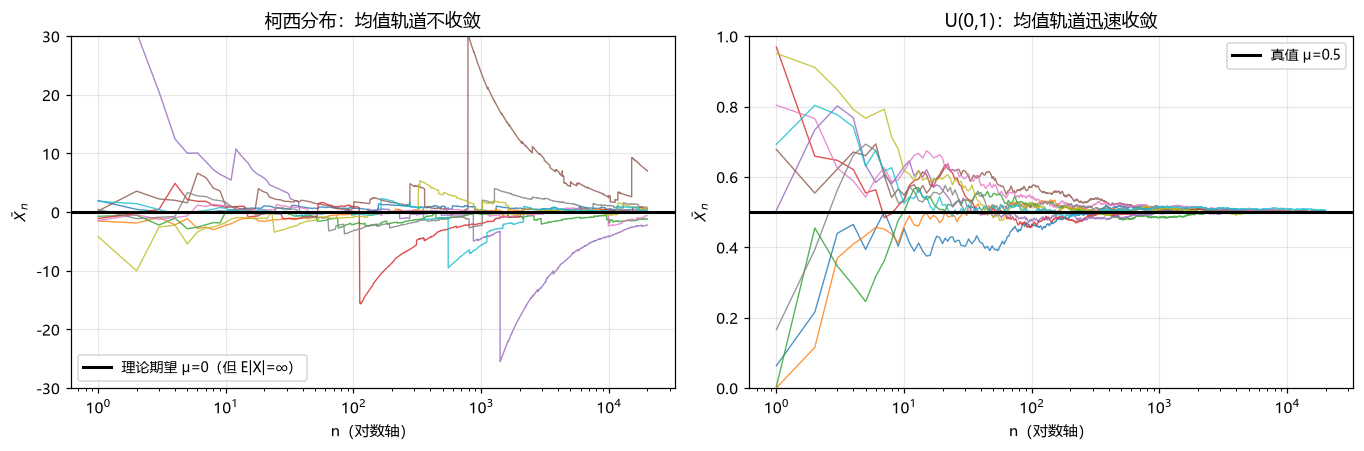

柯西 n=   100:  样本均值的 5%/50%/95% 分位 =    -6.34 /   0.01 /     6.24
柯西 n=  1000:  样本均值的 5%/50%/95% 分位 =    -5.77 /  -0.02 /     6.74


柯西 n= 10000:  样本均值的 5%/50%/95% 分位 =    -5.89 /  -0.03 /     6.39


柯西 n= 20000:  样本均值的 5%/50%/95% 分位 =    -5.69 /   0.02 /     6.56

均匀 n=   100:  样本均值的 5%/50%/95% 分位 =   0.4523 / 0.5009 /   0.5482
均匀 n=  1000:  样本均值的 5%/50%/95% 分位 =   0.4851 / 0.5001 /   0.5151
均匀 n= 10000:  样本均值的 5%/50%/95% 分位 =   0.4951 / 0.4999 /   0.5047


均匀 n= 20000:  样本均值的 5%/50%/95% 分位 =   0.4967 / 0.5000 /   0.5033

柯西：分位数区间随 n 完全不收缩（甚至更宽）；均匀：区间以 1/√n 收缩。


In [6]:
# ---- 反例实验：柯西 vs 均匀，样本均值的轨道对比 ----
N, K = 20000, 10
idx = np.arange(1, N + 1)

cauchy_paths = np.cumsum(rng.standard_cauchy((K, N)), axis=1) / idx
unif_paths = np.cumsum(rng.random((K, N)), axis=1) / idx

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for k in range(K):
    axes[0].plot(idx, cauchy_paths[k], lw=0.9, alpha=0.8)
axes[0].axhline(0, color='k', lw=2, label='理论期望 μ=0（但 E|X|=∞）')
axes[0].set_ylim(-30, 30); axes[0].set_xscale('log')
axes[0].set_title('柯西分布：均值轨道不收敛')
axes[0].set_xlabel('n（对数轴）'); axes[0].set_ylabel(r'$\bar X_n$')
axes[0].legend(fontsize=9)

for k in range(K):
    axes[1].plot(idx, unif_paths[k], lw=0.9, alpha=0.8)
axes[1].axhline(0.5, color='k', lw=2, label='真值 μ=0.5')
axes[1].set_ylim(0, 1); axes[1].set_xscale('log')
axes[1].set_title('U(0,1)：均值轨道迅速收敛')
axes[1].set_xlabel('n（对数轴）'); axes[1].set_ylabel(r'$\bar X_n$')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# 定量说明：柯西的样本均值在 n 增大后依然剧烈跳动
for n_ in [100, 1000, 10000, 20000]:
    m = rng.standard_cauchy((4000, n_)).mean(axis=1)
    print(f'柯西 n={n_:>6d}:  样本均值的 5%/50%/95% 分位 = '
          f'{np.percentile(m,5):8.2f} / {np.percentile(m,50):6.2f} / {np.percentile(m,95):8.2f}')
print()
for n_ in [100, 1000, 10000, 20000]:
    m = rng.random((4000, n_)).mean(axis=1)
    print(f'均匀 n={n_:>6d}:  样本均值的 5%/50%/95% 分位 = '
          f'{np.percentile(m,5):8.4f} / {np.percentile(m,50):6.4f} / {np.percentile(m,95):8.4f}')
print('\n柯西：分位数区间随 n 完全不收缩（甚至更宽）；均匀：区间以 1/√n 收缩。')

## 1.7 收敛速率：$1/\sqrt n$ 到底有多快？

LLN 只告诉我们「会收敛」，不告诉我们「多快」。但我们其实早就知道答案：

$$\mathrm{SE}(\bar X_n)=\frac{\sigma}{\sqrt n}\quad\Longrightarrow\quad \text{误差典型大小}\propto \frac{1}{\sqrt n}$$

**这条 $n^{-1/2}$ 律是概率论中最实用的结论之一**，它的直接推论是：

| 想要误差减半 | 需要样本量 ×4 |
|---|---|
| 想要误差降为 1/10 | 需要样本量 ×100 |

下面用实验验证：$\big|\bar X_n-\mu\big|$ 的中位数是否严格按 $n^{-1/2}$ 衰减，并且**常数**是否恰好等于 $\sigma\cdot(\text{标准正态绝对值的中位数})$。

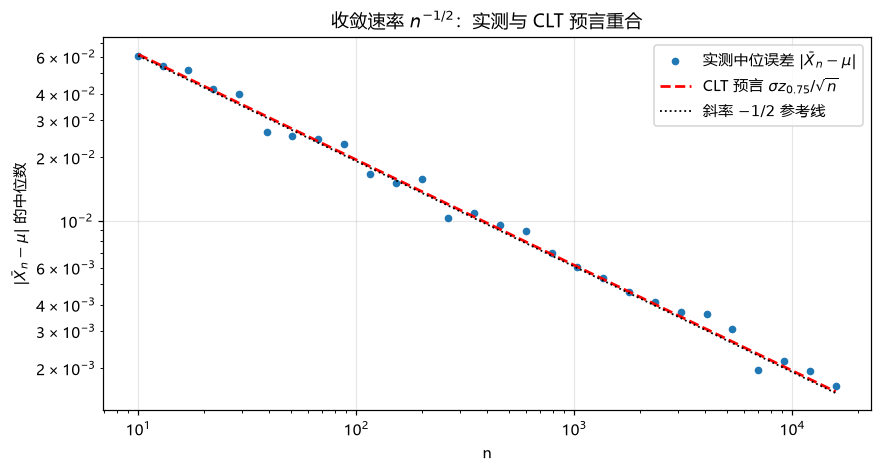

理论常数 σ·z_0.75 = 0.19471
结论：LLN 给出"收敛"，CLT 给出"以 n^{-1/2} 收敛、常数是 σ·0.6745"。
      —— 这正是 CLT 比 LLN 信息量更大的地方。


In [7]:
# ---- 验证 |X_bar - mu| 的中位数 ∝ n^{-1/2}，且常数由 CLT 给出 ----
sigma = 1 / np.sqrt(12)          # U(0,1) 的标准差
mu = 0.5
ns = np.unique(np.logspace(1, 4.2, 28).astype(int))
reps = 200

med_err = []
for n_ in ns:
    m = rng.random((reps, n_)).mean(axis=1)
    med_err.append(np.median(np.abs(m - mu)))
med_err = np.array(med_err)

# CLT 预言：sqrt(n)(X_bar-mu) -> N(0,sigma^2)
# 所以 |X_bar-mu| 的中位数 ~ sigma * z_0.75 / sqrt(n)，其中 z_0.75 = 0.6745
z75 = ND.inv_cdf(0.75)
theory = sigma * z75 / np.sqrt(ns)

plt.figure(figsize=(9, 4.4))
plt.loglog(ns, med_err, 'o', ms=4, label=r'实测中位误差 $|\bar X_n-\mu|$')
plt.loglog(ns, theory, 'r--', lw=1.8,
           label=r'CLT 预言 $\sigma z_{0.75}/\sqrt{n}$')
# 参考斜率线
ref = med_err[0] * (ns / ns[0]) ** -0.5
plt.loglog(ns, ref, 'k:', lw=1.2, label=r'斜率 $-1/2$ 参考线')
plt.xlabel('n'); plt.ylabel(r'$|\bar X_n-\mu|$ 的中位数')
plt.title(r'收敛速率 $n^{-1/2}$：实测与 CLT 预言重合')
plt.legend(); plt.show()

print(f'理论常数 σ·z_0.75 = {sigma * z75:.5f}')
print('结论：LLN 给出"收敛"，CLT 给出"以 n^{-1/2} 收敛、常数是 σ·0.6745"。')
print('      —— 这正是 CLT 比 LLN 信息量更大的地方。')

---
# 第 2 章　中心极限定理（Central Limit Theorem）

## 2.1 从 LLN 的「不足」说起

LLN 告诉我们 $\bar X_n\to\mu$，但如果你真的去做实验，会发现一个恼人的现象：

> **每次实验得到的 $\bar X_n$ 都不一样。**

即使 $n=10000$，两次实验的 $\bar X_n$ 仍有微小差别。这个差别的**大小和形状**，LLN 一个字都没说。

CLT 就是来补这个缺口的。它说的是：

$$\text{误差}\ \bar X_n-\mu\ \text{虽然趋于 }0,\ \text{但把它放大}\ \sqrt n\ \text{倍后，它有一个稳定的分布}$$

## 2.2 定理陈述

### 定理（Lindeberg–Lévy CLT，i.i.d. 情形）

设 $X_1,X_2,\dots$ 独立同分布，$\mathbb E[X_1]=\mu$，$\operatorname{Var}(X_1)=\sigma^2\in(0,\infty)$。令

$$Z_n:=\frac{\bar X_n-\mu}{\sigma/\sqrt n}=\frac{S_n-n\mu}{\sigma\sqrt n},\qquad S_n=\sum_{i=1}^n X_i$$

则

$$\boxed{\ Z_n\ \xrightarrow{\ d\ }\ N(0,1)\ }$$

即对任意 $x\in\mathbb R$：

$$\lim_{n\to\infty}P(Z_n\le x)=\Phi(x)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x}e^{-t^2/2}\,dt$$

### 三种等价写法（考试与工程中都用得到）

$$\frac{\bar X_n-\mu}{\sigma/\sqrt n}\xrightarrow{d}N(0,1)
\quad\Longleftrightarrow\quad
\bar X_n\ \dot\sim\ N\!\left(\mu,\frac{\sigma^2}{n}\right)
\quad\Longleftrightarrow\quad
S_n\ \dot\sim\ N\!\left(n\mu,n\sigma^2\right)$$

符号 $\dot\sim$ 读作「近似服从」。

### 三个必须记住的要点

1. **不需要知道 $X_i$ 的分布**。$X_i$ 可以是伯努利、均匀、指数、泊松、双峰、甚至离散的骰子 —— 和的标准化的极限都是同一个 $N(0,1)$。这叫**普适性（universality）**。
2. **条件极弱**：只要独立同分布 + 方差有限。对比 LLN 只要一阶矩，CLT 需要二阶矩。
3. **收敛的是分布，不是数值**：$Z_n$ 本身不收敛（它一直在随机跳动），收敛的是它的**分布函数**。

## 2.3 证明：特征函数路线（完整推导）

### 证明策略概览

```
S_n = X_1 + ... + X_n          「求和」在分布层面 = 卷积
        ↓ 取特征函数
φ_{S_n}(t) = [φ_X(t)]^n        「卷积」变成了「乘积」
        ↓ 标准化 + 泰勒展开
φ_{Z_n}(t) = [φ_X(t/(σ√n))]^n  「取对数 + 展开」得到 (1 - t²/(2n))^n
        ↓ 取极限
           → e^{-t²/2}         这正是 N(0,1) 的特征函数
        ↓ Lévy 连续性定理
Z_n → N(0,1) 依分布
```

### Step 1：标准化的技术准备

不失一般性，令 $\mu=0,\ \sigma^2=1$（否则用 $Y_i=(X_i-\mu)/\sigma$ 替换，$Y_i$ 满足条件且 $Z_n$ 不变）。于是

$$Z_n=\frac{1}{\sqrt n}\sum_{i=1}^n X_i$$

### Step 2：用特征函数表示 $Z_n$ 的分布

由 $\varphi_{X+Y}=\varphi_X\varphi_Y$（独立）和 $\varphi_{cX}(t)=\varphi_X(ct)$（线性变换）：

$$\varphi_{Z_n}(t)=\mathbb E\left[\exp\left(it\cdot\frac{1}{\sqrt n}\sum_{i=1}^n X_i\right)\right]
=\prod_{i=1}^n\mathbb E\left[e^{i(t/\sqrt n)X_i}\right]
=\left[\varphi_X\!\left(\frac{t}{\sqrt n}\right)\right]^{n}$$

**这一步是整个证明的核心。** 卷积的痛苦被一次傅里叶变换彻底消解。

### Step 3：泰勒展开 $\varphi_X$

因为 $\mathbb E[X]=0,\ \mathbb E[X^2]=1$，特征函数在 $0$ 附近有展开：

$$\varphi_X(u)=\mathbb E[e^{iuX}]=\mathbb E\left[1+iuX-\frac{u^2X^2}{2}+O(|u|^3|X|^3)\right]
=1+iu\underbrace{\mathbb E[X]}_{0}-\frac{u^2}{2}\underbrace{\mathbb E[X^2]}_{1}+o(u^2)$$

$$=1-\frac{u^2}{2}+o(u^2)\qquad(u\to 0)$$

> **技术细节**：$o(u^2)$ 这一项需要「一致可积」的论证。严格做法是先用 $|e^{iux}-1-iux+\frac{u^2x^2}{2}|\le \min(\frac{u^2x^2}{2},\ |u|^3|x|^3)$ 控制余项，再对 $\mathbb E[X^2]<\infty$ 做截断处理。这一步是 Lindeberg 条件的原始动机。

代入 $u=t/\sqrt n$：

$$\varphi_X\!\left(\frac{t}{\sqrt n}\right)=1-\frac{t^2}{2n}+o\!\left(\frac{1}{n}\right)$$

### Step 4：取 $n$ 次方，用 $\log$ 技巧

直接算 $\left(1-\frac{t^2}{2n}+o(\frac1n)\right)^n$ 不好处理，取对数：

$$\log\varphi_{Z_n}(t)=n\log\left[1-\frac{t^2}{2n}+o\!\left(\frac1n\right)\right]$$

利用 $\log(1+w)=w+O(w^2)$（$w\to0$），其中 $w=-\frac{t^2}{2n}+o(\frac1n)$：

$$n\log\varphi_{Z_n}(t)=n\left[-\frac{t^2}{2n}+o\!\left(\frac1n\right)+O\!\left(\frac{1}{n^2}\right)\right]
=-\frac{t^2}{2}+n\cdot o\!\left(\frac1n\right)\xrightarrow{n\to\infty}-\frac{t^2}{2}$$

所以

$$\varphi_{Z_n}(t)\xrightarrow{n\to\infty}\exp\left(-\frac{t^2}{2}\right)$$

### Step 5：认出这是正态分布

标准正态 $N(0,1)$ 的特征函数可以直接算出（配方 + 高斯积分）：

$$\varphi_{N(0,1)}(t)=\int_{-\infty}^{\infty}e^{itx}\frac{1}{\sqrt{2\pi}}e^{-x^2/2}dx
=e^{-t^2/2}\underbrace{\int_{-\infty}^{\infty}\frac{1}{\sqrt{2\pi}}e^{-(x-it)^2/2}dx}_{=1}=e^{-t^2/2}$$

### Step 6：Lévy 连续性定理收尾

**定理（Lévy）**：若 $\varphi_{Z_n}(t)\to\varphi(t)$ 对每个 $t$ 成立，且 $\varphi$ 在 $t=0$ 连续，则存在分布 $F$ 使 $Z_n\xrightarrow{d}F$，且 $\varphi$ 就是 $F$ 的特征函数。

我们已经证明 $\varphi_{Z_n}(t)\to e^{-t^2/2}$，而 $e^{-t^2/2}$ 正是 $N(0,1)$ 的特征函数且处处连续。由特征函数的**唯一性**：

$$Z_n\ \xrightarrow{\ d\ }\ N(0,1).\qquad\blacksquare$$

## 2.4 深层问题：为什么偏偏是正态分布？

证明只说明了「极限是 $e^{-t^2/2}$」，但没解释**为什么它必须长这样**。这里有四个互补的解释，从不同角度指向同一个答案。

### 解释 1：正态分布是「求和操作的不动点」

考虑一个映射 $\mathcal T$：把分布 $F$ 映到「两个独立 $F$ 之和再标准化」的分布。

$$\mathcal T(F)=\text{Law}\left(\frac{X_1+X_2-\text{中心}}{\text{尺度}}\right),\qquad X_1,X_2\overset{iid}{\sim}F$$

CLT 说：**任何方差有限的 $F$，反复应用 $\mathcal T$ 都会收敛到 $N(0,1)$**。而 $N(0,1)$ 本身满足

$$X_1,X_2\sim N(0,1)\ \text{独立}\ \Longrightarrow\ \frac{X_1+X_2}{\sqrt 2}\sim N(0,1)$$

也就是说 **$N(0,1)$ 是 $\mathcal T$ 的不动点**。

> 在特征函数语言里，这最清楚：设 $\psi(t)=\log\varphi(t)$。不动点方程是
> $$2\psi\!\left(\frac{t}{\sqrt 2}\right)=\psi(t)$$
> 它的解正是 $\psi(t)=-ct^2/2$，即 $\varphi(t)=e^{-ct^2/2}$。**正态分布是唯一（在二阶矩有限类中）满足「除以 $\sqrt2$ 后分布不变」的分布。**

### 解释 2：稳定分布族 —— 正态是「唯一有有限方差的稳定分布」

**稳定分布**的定义：若 $X_1,\dots,X_n$ i.i.d. $\sim F$，存在常数 $a_n>0,b_n$ 使得

$$\frac{X_1+\cdots+X_n-b_n}{a_n}\overset{d}{=}X_1$$

则称 $F$ 为稳定分布。它由两个参数刻画，特征函数为

$$\varphi(t)=\exp\left(i\delta t-\gamma|t|^\alpha\left[1+i\beta\,\mathrm{sgn}(t)\,\omega(t,\alpha)\right]\right)$$

| 参数 $\alpha$ | 分布 | 方差 | 归一化尺度 $a_n$ |
|---|---|---|---|
| $\alpha=2$ | **正态** | 有限 | $\sqrt n$ |
| $\alpha=1$ | **柯西** | 无穷 | $n$ |
| $\alpha=0.5$ | Lévy | 无穷 | $n^2$ |
| $0<\alpha<2$ | 其他稳定分布 | 无穷 | $n^{1/\alpha}$ |

**关键结论**：

- 方差有限 $\Rightarrow$ $\alpha=2$ $\Rightarrow$ 极限只能是正态。这就是 CLT 的本质：**不是「正态特殊」，而是「方差有限这个条件把稳定分布族中的其他成员全部排除掉了」**。
- 柯西（$\alpha=1$）也满足自己的「CLT」，但尺度是 $n$ 而不是 $\sqrt n$，且极限是柯西本身。这解释了 1.6 节的实验现象。

### 解释 3：最大熵 —— 正态是「给定方差下最不确定」的分布

在约束 $\int f=1$、$\int x^2f=\sigma^2$ 下最大化微分熵

$$h(f)=-\int f(x)\log f(x)\,dx$$

用拉格朗日乘子法：$\mathcal L=-\int f\log f-\lambda_0(\int f-1)-\lambda_1(\int x^2f-\sigma^2)$，变分得

$$-\log f(x)-1-\lambda_0-\lambda_1x^2=0\ \Longrightarrow\ f(x)=Ce^{-\lambda_1x^2}$$

即正态分布。**从信息论看：正态分布是「只知均值和方差时，最不武断的假设」。** 这是为什么在深度学习中，把噪声假设为正态往往是最少附加假设的选择。

### 解释 4：与「重对数律」的对照 —— 看清楚 $\sqrt n$ 的临界性

把误差 $\bar X_n-\mu$ 放大 $g(n)$ 倍，结果取决于 $g$ 的选取：

| 放大倍数 $g(n)$ | 结果 | 定理 |
|---|---|---|
| $1$ | $\to 0$ | LLN |
| $\sqrt n$ | $\xrightarrow{d}N(0,\sigma^2)$，**不收敛到 0** | **CLT** |
| $\sqrt{n\log\log n}$ | $\xrightarrow{a.s.}$ 在 $\pm\sigma$ 之间**震荡** | 重对数律 LIL |
| $n$ | $\to\infty$ | —— |

**$\sqrt n$ 是一条精确的临界线**：

- 放大不足（$g\ll\sqrt n$）：误差被压没了；
- 放大过度（$g\gg\sqrt n$）：误差被放大到无穷；
- 恰好 $\sqrt n$：误差停在一个有界的、有形状的随机变量上。

而重对数律告诉我们更精细的事实：**几乎必然地**，

$$\limsup_{n\to\infty}\frac{\bar X_n-\mu}{\sigma\sqrt{\log\log n /n}}=\sqrt 2\ \text{（a.s.）}$$

即真实轨道的波动幅度是 $\sigma\sqrt{2\log\log n/n}$，只比 $\sigma/\sqrt n$ 大了**一个 $\sqrt{\log\log n}$**。所以 CLT 描述的 $\sqrt n$ 尺度是「几乎必然成立的上界」的极慢修正版本 —— 这也是为什么 $\sqrt n$ 律在实践中如此稳健。

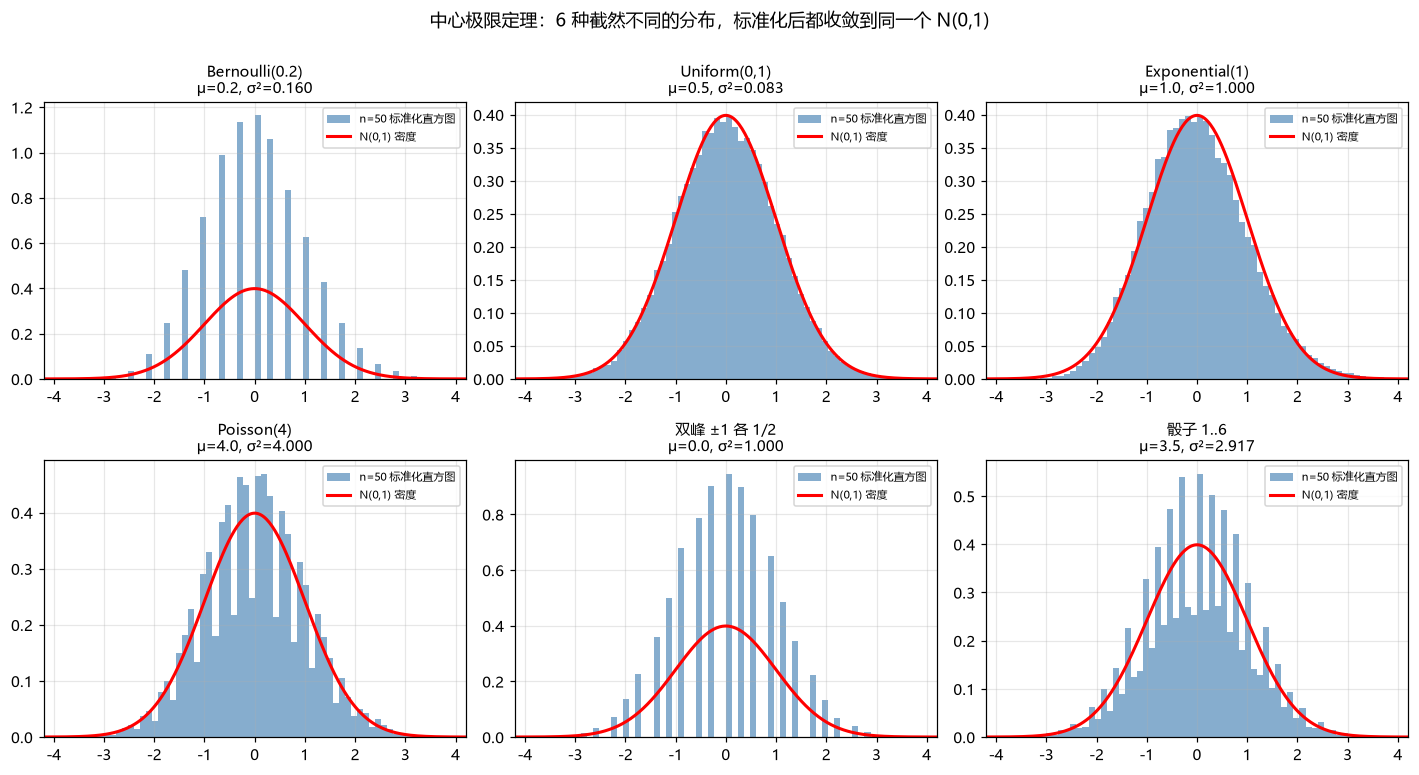

注意"双峰 ±1"：原始分布是两个尖峰（最不像正态的分布之一），
但 n=50 的和已经几乎是完美的钟形 —— 这就是 CLT 的普适性。


In [8]:
# ---- CLT 的核心实验：不同分布，同一个极限 ----
# 从完全不同的分布出发，标准化后都塌到同一个 N(0,1)
dists = {
    'Bernoulli(0.2)':      (lambda n: rng.random(n) < 0.2,                    0.2,      0.16),
    'Uniform(0,1)':        (lambda n: rng.random(n),                          0.5,      1/12),
    'Exponential(1)':      (lambda n: rng.exponential(1.0, n),                1.0,      1.0),
    'Poisson(4)':          (lambda n: rng.poisson(4.0, n),                    4.0,      4.0),
    '双峰 ±1 各 1/2':       (lambda n: rng.choice([-1.0, 1.0], n),             0.0,      1.0),
    '骰子 1..6':            (lambda n: rng.integers(1, 7, n).astype(float),    3.5,      35/12),
}

n, reps = 50, 40000
xs = np.linspace(-4.2, 4.2, 300)
phi = np.array([ND.pdf(x) for x in xs])

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, (gen, mu, var)) in zip(axes.ravel(), dists.items()):
    s = np.array([gen(n) for _ in range(reps)])       # reps × n
    z = (s.mean(axis=1) - mu) / np.sqrt(var / n)      # 标准化

    ax.hist(z, bins=70, range=(-4.2, 4.2), density=True,
            color='steelblue', alpha=0.65, label=f'n={n} 标准化直方图')
    ax.plot(xs, phi, 'r-', lw=2, label='N(0,1) 密度')
    ax.set_title(f'{name}\nμ={mu}, σ²={var:.3f}', fontsize=10)
    ax.set_xlim(-4.2, 4.2)
    ax.legend(fontsize=7.5)

plt.suptitle('中心极限定理：6 种截然不同的分布，标准化后都收敛到同一个 N(0,1)', y=1.00)
plt.tight_layout(); plt.show()
print('注意"双峰 ±1"：原始分布是两个尖峰（最不像正态的分布之一），')
print('但 n=50 的和已经几乎是完美的钟形 —— 这就是 CLT 的普适性。')

## 2.5 收敛有多快？Berry–Esseen 定理

CLT 是极限定理，$n\to\infty$ 才有保证。实践中 $n$ 有限，我们需要知道**误差的量级**。

### 定理（Berry–Esseen）

在 i.i.d. 且 $\mathbb E|X|^3<\infty$ 的条件下，存在**绝对常数** $C$（使得不等式对所有分布成立的最小 $C$ 满足 $0.4097<C<0.4748$）使得

$$\sup_{x\in\mathbb R}\left|P(Z_n\le x)-\Phi(x)\right|\ \le\ \frac{C\,\rho}{\sigma^3\sqrt n}$$

其中 $\rho=\mathbb E|X-\mu|^3$ 是**三阶绝对中心矩**。

### 这个定理告诉我们什么

1. **收敛速度是 $n^{-1/2}$** —— 和 $\mathrm{SE}$ 的衰减同阶。想要把分布近似的最大误差减半，需要样本量 ×4。
2. **误差取决于偏度**。记偏度 $\gamma_1=\mathbb E[(X-\mu)^3]/\sigma^3$（正态的 $\gamma_1=0$），则误差的**主导项**正比于 $\gamma_1$：

$$\sup_x|P(Z_n\le x)-\Phi(x)|\ \approx\ \frac{\gamma_1}{6\sqrt{2\pi e}}\cdot\frac{1}{\sqrt n}+O\!\left(\frac{1}{n}\right)$$

（严格的上界用的是三阶绝对矩比 $\rho/\sigma^3$，正态时它等于 $2\sqrt{2/\pi}\approx1.596$，与 $\gamma_1$ 无关。）

**偏度越大，需要的 $n$ 越大。** 这解释了为什么：
- 对称分布（均匀、双峰）$n=10$ 就很像正态；
- 强偏分布（指数、对数正态、几何）$n$ 要上百才像正态。

3. **$n^{-1/2}$ 不能改进**。存在分布使误差恰好是 $\Theta(n^{-1/2})$。所以 CLT 的收敛速度是**本质的**，不是证明技巧的不足。

### 常用分布的偏度对照

| 分布 | 偏度 $\gamma_1$ | $n=10$ 时像正态吗 | $n$ 需要多大 |
|---|---|---|---|
| 均匀 $U(0,1)$ | $0$ | 很像 | $\sim5$ |
| 双峰 $\pm1$ | $0$ | 很像 | $\sim10$ |
| 正态 | $0$ | 精确 | —— |
| 泊松(4) | $1/\sqrt4=0.5$ | 还行 | $\sim30$ |
| 伯努利(0.2) | $1.34$ | 一般 | $\sim50$ |
| 指数(1) | $2$ | 明显右偏 | $\sim100$ |
| 对数正态 | $6.2$ | 严重右偏 | $\sim10^4$ |

> **实践建议**：如果你要用正态近似一个和，先看偏度。$\gamma_1/\sqrt n<0.3$ 时近似通常可以接受。

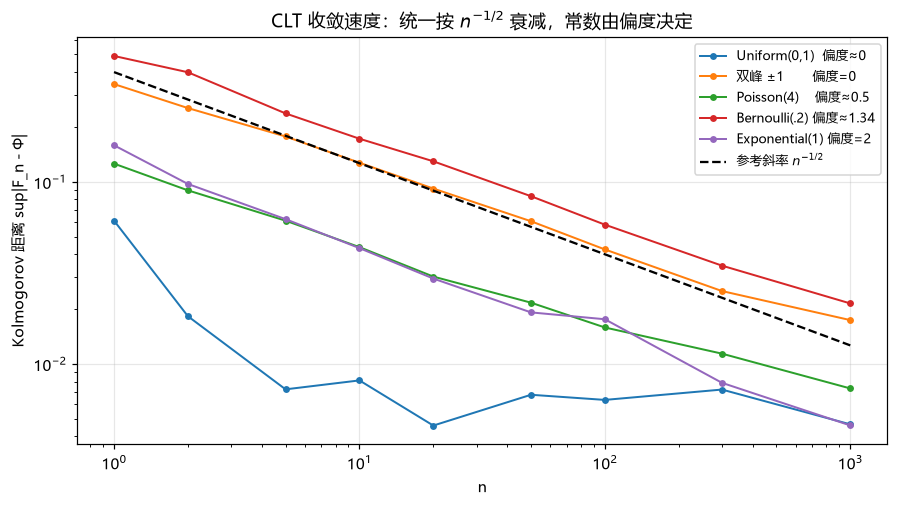

读数要点：
  1) 所有曲线斜率都接近 -1/2（平行于黑色虚线）→ 印证 Berry-Esseen 的 n^{-1/2}；
  2) 曲线的高低顺序与偏度顺序完全一致 → 偏度越大，常数越大；
  3) 对数正态这类 γ₁≈6 的分布会高出几条街（未画入，因需要 n~1e4 才收敛）。


In [9]:
# ---- 实验：收敛速度如何受偏度支配？----
# 对每个分布，画 n 增大时"标准化直方图 vs N(0,1)"的最大偏差
def skewness(x):
    m, s = x.mean(), x.std()
    return np.mean(((x - m) / s) ** 3)

cases = {
    'Uniform(0,1)  偏度≈0':        (lambda k: rng.random(k),               0.5,  1/12),
    '双峰 ±1       偏度=0':        (lambda k: rng.choice([-1.,1.], k),     0.0,  1.0),
    'Poisson(4)    偏度≈0.5':      (lambda k: rng.poisson(4., k),          4.0,  4.0),
    'Bernoulli(.2) 偏度≈1.34':     (lambda k: (rng.random(k) < .2).astype(float), 0.2, 0.16),
    'Exponential(1) 偏度=2':       (lambda k: rng.exponential(1., k),      1.0,  1.0),
}

ns = [1, 2, 5, 10, 20, 50, 100, 300, 1000]
xs = np.linspace(-4, 4, 200)
phi = np.array([ND.pdf(x) for x in xs])

plt.figure(figsize=(9.5, 4.8))
for name, (gen, mu, var) in cases.items():
    errs = []
    for n_ in ns:
        z = (gen((30000, n_)).mean(axis=1) - mu) / np.sqrt(var / n_)
        # 经验 CDF 与 Φ 的最大偏差（Kolmogorov 型距离）
        zs = np.sort(z)
        ecdf = np.arange(1, len(zs) + 1) / len(zs)
        errs.append(np.max(np.abs(ecdf - np.array([ND.cdf(v) for v in zs]))))
    plt.loglog(ns, errs, 'o-', ms=3.5, lw=1.3, label=name)

ref = 0.4 / np.sqrt(np.array(ns, dtype=float))
plt.loglog(ns, ref, 'k--', lw=1.5, label=r'参考斜率 $n^{-1/2}$')
plt.xlabel('n'); plt.ylabel('Kolmogorov 距离 sup|F_n - Φ|')
plt.title('CLT 收敛速度：统一按 $n^{-1/2}$ 衰减，常数由偏度决定')
plt.legend(fontsize=8.5); plt.show()

print('读数要点：')
print('  1) 所有曲线斜率都接近 -1/2（平行于黑色虚线）→ 印证 Berry-Esseen 的 n^{-1/2}；')
print('  2) 曲线的高低顺序与偏度顺序完全一致 → 偏度越大，常数越大；')
print('  3) 对数正态这类 γ₁≈6 的分布会高出几条街（未画入，因需要 n~1e4 才收敛）。')

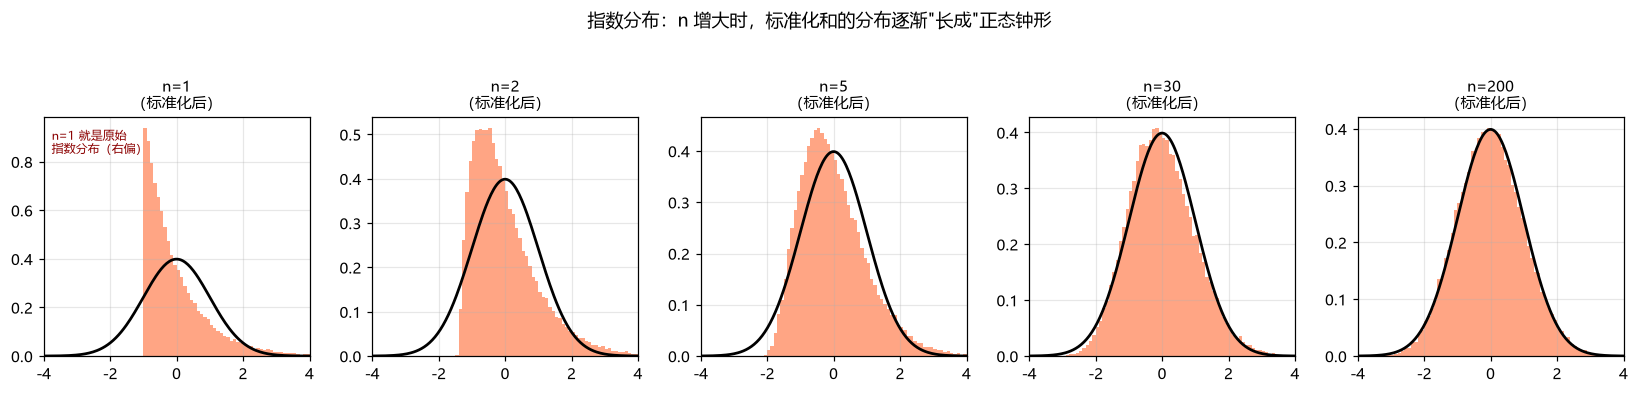

指数分布的偏度 γ₁ = 1.999（理论值 2）
对比：n=1 严重右偏 → n=5 已经对称 → n=30 之后基本看不出差别。


In [10]:
# ---- 可视化：从 n=1 到 n=100 的"变形过程" ----
# 用指数分布（强偏）看分布形状如何一步步变成钟形
mu_e, var_e = 1.0, 1.0
ns_show = [1, 2, 5, 30, 200]

fig, axes = plt.subplots(1, len(ns_show), figsize=(15, 3.4))
for ax, n_ in zip(axes, ns_show):
    z = (rng.exponential(1.0, (60000, n_)).mean(axis=1) - mu_e) / np.sqrt(var_e / n_)
    ax.hist(z, bins=80, range=(-4, 4), density=True, color='coral', alpha=0.7)
    ax.plot(xs, phi, 'k-', lw=1.8)
    sk = skewness(rng.exponential(1.0, 200000))
    ax.set_title(f'n={n_}\n（标准化后）', fontsize=10)
    ax.set_xlim(-4, 4)
    if n_ == 1:
        ax.text(0.03, 0.85, 'n=1 就是原始\n指数分布（右偏）',
                transform=ax.transAxes, fontsize=8, color='darkred')

plt.suptitle('指数分布：n 增大时，标准化和的分布逐渐"长成"正态钟形', y=1.04)
plt.tight_layout(); plt.show()

print(f'指数分布的偏度 γ₁ = {skewness(rng.exponential(1.0, 400000)):.3f}（理论值 2）')
print('对比：n=1 严重右偏 → n=5 已经对称 → n=30 之后基本看不出差别。')

## 2.6 推广：当「独立同分布」被放松

i.i.d. 条件太强了。现实中样本常常**独立但不同分布**（不同批次的测量、不同来源的数据），或者**同分布但不独立**（时间序列）。下面三条推广覆盖了绝大多数实际需求。

### 推广 1：Lindeberg–Feller CLT（独立但不同分布）

设 $X_1,X_2,\dots$ **独立**（不要求同分布），$\mathbb E[X_i]=\mu_i$，$\operatorname{Var}(X_i)=\sigma_i^2$。记

$$s_n^2=\sum_{i=1}^n\sigma_i^2,\qquad Z_n=\frac{1}{s_n}\sum_{i=1}^n(X_i-\mu_i)$$

若满足 **Lindeberg 条件**：对任意 $\varepsilon>0$，

$$\frac{1}{s_n^2}\sum_{i=1}^n\mathbb E\left[(X_i-\mu_i)^2\mathbf 1_{\{|X_i-\mu_i|>\varepsilon s_n\}}\right]\xrightarrow{n\to\infty}0$$

则 $Z_n\xrightarrow{d}N(0,1)$。

**Lindeberg 条件的含义**：没有任何单个 $X_i$ 能「主导」整个和的波动。等价说法是

$$\max_{1\le i\le n}\frac{\sigma_i^2}{s_n^2}\xrightarrow{n\to\infty}0$$

即**最大单项方差占总方差的比例趋于 0**。这是 CLT 真正的本质条件 —— 不是「同分布」，而是「**没有主导项**」。

> **反例**：若 $X_1\sim N(0,1)$ 而 $X_2=X_3=\cdots=0$（方差全在 $X_1$ 上），则 $s_n^2=1$，$Z_n=X_1$ 恒等于 $N(0,1)$，CLT 平凡成立但无意义。若改成 $X_1\sim\mathrm{Cauchy}$、其余为 0，则 Lindeberg 条件破坏，CLT 不成立。

### 推广 2：Lyapunov CLT（更好验证的充分条件）

若存在 $\delta>0$ 使

$$\frac{1}{s_n^{2+\delta}}\sum_{i=1}^n\mathbb E|X_i-\mu_i|^{2+\delta}\xrightarrow{n\to\infty}0$$

则 CLT 成立。Lyapunov 条件比 Lindeberg 强（更易验证），取 $\delta=1$ 时即三阶矩条件。

### 推广 3：多维 CLT（向量值）

设 $\mathbf X_i\in\mathbb R^d$ i.i.d.，$\mathbb E[\mathbf X_i]=\boldsymbol\mu$，协方差矩阵 $\boldsymbol\Sigma=\mathbb E[(\mathbf X_i-\boldsymbol\mu)(\mathbf X_i-\boldsymbol\mu)^\top]$ 正定，则

$$\sqrt n\,(\bar{\mathbf X}_n-\boldsymbol\mu)\ \xrightarrow{\ d\ }\ N_d(\mathbf 0,\boldsymbol\Sigma)$$

其中 $N_d$ 的密度为 $\frac{1}{(2\pi)^{d/2}|\boldsymbol\Sigma|^{1/2}}\exp\left(-\frac12(\mathbf x-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf x-\boldsymbol\mu)\right)$。

**这条推广在深度学习里极其重要**：神经网络的梯度就是一个高维向量，SGD 的梯度噪声正是用多维 CLT 来刻画的。

### 推广 4：Delta 方法（非线性函数的 CLT）

CLT 只管「和」，但我们常常需要**和的光滑函数**。设 $\sqrt n(\bar X_n-\mu)\xrightarrow{d}N(0,\sigma^2)$，$g$ 在 $\mu$ 处可微且 $g'(\mu)\ne0$，则由一阶泰勒展开

$$g(\bar X_n)=g(\mu)+g'(\mu)(\bar X_n-\mu)+o_p(\bar X_n-\mu)$$

得

$$\boxed{\ \sqrt n\big(g(\bar X_n)-g(\mu)\big)\ \xrightarrow{\ d\ }\ N\!\left(0,\ \big[g'(\mu)\big]^2\sigma^2\right)\ }$$

**直觉**：在 $\mu$ 附近，$g$ 近似是线性的，所以 $g$ 把正态「拉伸」了 $g'(\mu)$ 倍，方差被乘上 $[g'(\mu)]^2$。

**经典应用**：用样本方差 $S_n^2$ 估计 $\sigma^2$，或估计标准差 $\sqrt{S_n^2}$、变异系数、相关系数、MLE 的渐近分布 —— 全都是 Delta 方法的例子。

> **在深度学习里**：把 $g$ 取成损失函数 $L$，就得到「SGD 的平稳点附近，参数的渐近分布是正态」，这是 SAM、SWA、贝叶斯深度学习等方法的理论基础。

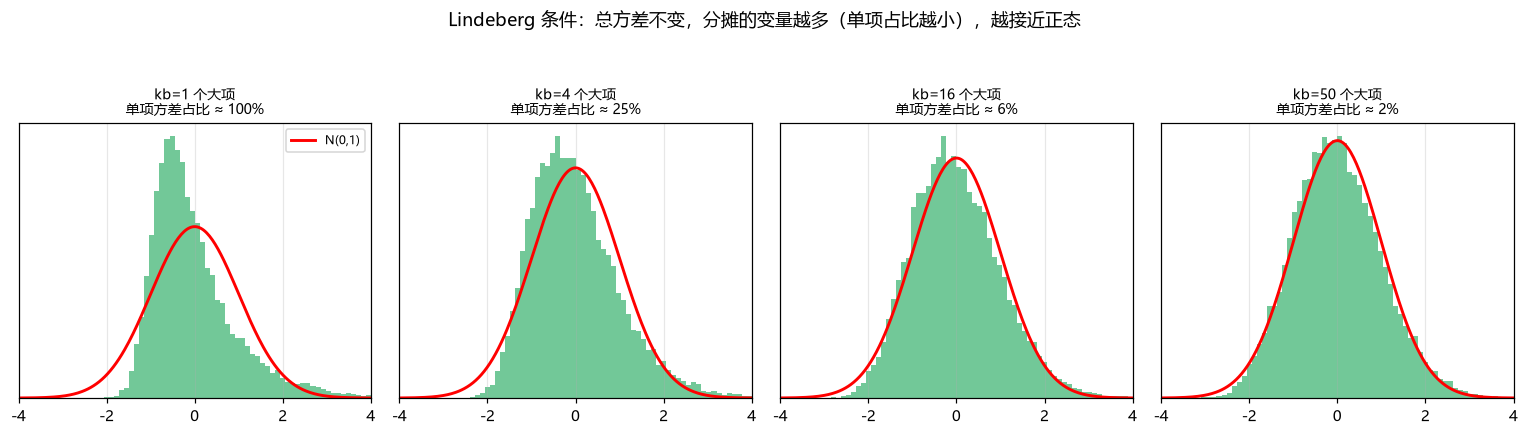

kb=1  ：一个指数项独占 100% 方差 → 形状就是指数分布，严重右偏，CLT 失效；
kb=4  ：单项占比 25% → 已有明显改善但仍偏；
kb=16 ：单项占比 6%  → 基本贴合正态；
kb=50 ：单项占比 2%  → 与正态几乎无法区分。

这正是 Lindeberg 条件的含义：决定 CLT 成立的不是"是否同分布"，
而是"是否存在一个方差占比不趋于 0 的主导项"。


In [11]:
# ---- 验证 Lindeberg 条件的直觉：把"总大方差"分摊到多少个变量上 ----
# 设计：n=50 个独立变量，其中 kb 个是"大项"（指数分布，强偏），其余是 N(0,1)。
# 大项的方差总和固定为 400，平摊给 kb 个 → kb 越小，单项越"主导"。
def build(kb, n=50, total_big_var=400.0):
    z = rng.standard_normal((20000, n))
    if kb > 0:
        v = total_big_var / kb                 # 每个大项的方差
        rate = 1.0 / np.sqrt(v)                # Exp(rate) 的方差 = 1/rate^2 = v
        big = rng.exponential(1.0 / rate, (20000, kb)) - 1.0 / rate   # 中心化
        z[:, :kb] = big
    return z, kb * total_big_var / (kb * total_big_var + (n - kb) * 1.0)

xs2 = np.linspace(-4, 4, 250)
phi2 = np.array([ND.pdf(x) for x in xs2])

fig, axes = plt.subplots(1, 4, figsize=(14, 3.7))
for ax, kb in zip(axes, [1, 4, 16, 50]):
    z, max_ratio = build(kb)
    s = z.sum(axis=1)
    zn = (s - s.mean()) / s.std()
    ax.hist(zn, bins=70, range=(-4, 4), density=True, color='mediumseagreen', alpha=0.72)
    ax.plot(xs2, phi2, 'r-', lw=1.9, label='N(0,1)')
    ax.set_title(f'kb={kb} 个大项\n单项方差占比 ≈ {1/kb*100:.0f}%', fontsize=9)
    ax.set_xlim(-4, 4); ax.set_yticks([])
axes[0].legend(fontsize=8)

plt.suptitle('Lindeberg 条件：总方差不变，分摊的变量越多（单项占比越小），越接近正态', y=1.06)
plt.tight_layout(); plt.show()

print('kb=1  ：一个指数项独占 100% 方差 → 形状就是指数分布，严重右偏，CLT 失效；')
print('kb=4  ：单项占比 25% → 已有明显改善但仍偏；')
print('kb=16 ：单项占比 6%  → 基本贴合正态；')
print('kb=50 ：单项占比 2%  → 与正态几乎无法区分。')
print()
print('这正是 Lindeberg 条件的含义：决定 CLT 成立的不是"是否同分布"，')
print('而是"是否存在一个方差占比不趋于 0 的主导项"。')

## 2.7 经典应用：从「棣莫弗–拉普拉斯」到置信区间

### 应用 1：正态近似二项分布（最早版本的 CLT）

设 $S_n\sim\mathrm{Binomial}(n,p)$，把它写成 $S_n=\sum_{i=1}^n X_i$，$X_i\sim\mathrm{Bernoulli}(p)$ i.i.d.，则

$$\mu=np,\qquad \sigma^2=np(1-p)$$

CLT 立刻给出

$$P(S_n\le k)\ \approx\ \Phi\!\left(\frac{k-np}{\sqrt{np(1-p)}}\right)$$

这就是**棣莫弗–拉普拉斯定理**（1733 年，比一般 CLT 早了近 200 年）。

**连续性修正（continuity correction）**：$S_n$ 是离散的，而正态是连续的。用 $\Phi\left(\frac{k+0.5-np}{\sqrt{np(1-p)}}\right)$ 代替精度会显著提高，因为把整数 $k$ 对应的柱体 $[k-0.5,k+0.5]$ 完整包含进来了。

**经验法则**：当 $np\ge5$ 且 $n(1-p)\ge5$ 时，正态近似通常够用。

### 应用 2：置信区间与覆盖率

由 CLT，当 $n$ 足够大：

$$P\left(-1.96\le\frac{\bar X_n-\mu}{\sigma/\sqrt n}\le1.96\right)\approx0.95$$

反解出 $\mu$ 的区间：

$$\bar X_n\pm1.96\frac{\sigma}{\sqrt n}\qquad\text{（95\% 置信区间）}$$

**注意这里有两个层次的近似**：

1. CLT 保证 $\frac{\bar X_n-\mu}{\sigma/\sqrt n}$ 近似 $N(0,1)$；
2. 实践中 $\sigma$ 往往未知，用样本标准差 $S_n$ 代替 —— 由 **Slutsky 定理**（若 $Z_n\xrightarrow{d}Z$ 且 $A_n\xrightarrow{P}a$ 常数，则 $A_nZ_n\xrightarrow{d}aZ$），这个替换在 $n\to\infty$ 时无害。

下面的实验会展示：**覆盖率是 $n$ 的函数**，$n$ 太小的时候 95\% 区间实际只覆盖 80\% 多。

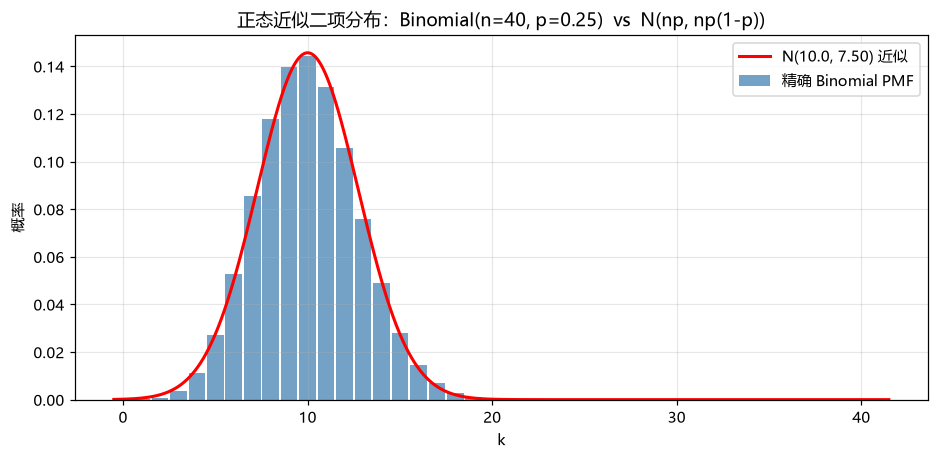

   k     精确 P(S<=k)         朴素正态        连续性修正
   5        0.04327      0.03394      0.05017
   8        0.29983      0.23260      0.29194
  10        0.58390      0.50000      0.57243
  12        0.82087      0.76740      0.81934
  15        0.97376      0.96606      0.97770

连续性修正把误差压小了一个数量级 —— 离散变量近似连续分布时的标准技巧。


In [12]:
# ---- 应用 1：正态近似二项分布 + 连续性修正 ----
from math import comb

n_b, p_b = 40, 0.25
mu_b, sd_b = n_b * p_b, np.sqrt(n_b * p_b * (1 - p_b))
ks = np.arange(0, n_b + 1)
pmf = np.array([comb(n_b, k) * p_b**k * (1 - p_b)**(n_b - k) for k in ks])

k_plot = np.arange(-0.5, n_b + 1.5, 0.01)
pdf_norm = np.array([ND.pdf((x - mu_b) / sd_b) / sd_b for x in k_plot])

plt.figure(figsize=(10, 4.3))
plt.bar(ks, pmf, width=0.9, color='steelblue', alpha=0.75, label='精确 Binomial PMF')
plt.plot(k_plot, pdf_norm, 'r-', lw=2,
         label=f'N({mu_b:.1f}, {sd_b**2:.2f}) 近似')
plt.xlabel('k'); plt.ylabel('概率')
plt.title(f'正态近似二项分布：Binomial(n={n_b}, p={p_b})  vs  N(np, np(1-p))')
plt.legend(); plt.show()

# 定量比较：P(S_n <= k) 的三种算法
print(f'{"k":>4} {"精确 P(S<=k)":>14} {"朴素正态":>12} {"连续性修正":>12}')
for k in [5, 8, 10, 12, 15]:
    exact = sum(comb(n_b, j) * p_b**j * (1 - p_b)**(n_b - j) for j in range(k + 1))
    naive = ND.cdf((k - mu_b) / sd_b)
    corr = ND.cdf((k + 0.5 - mu_b) / sd_b)
    print(f'{k:>4} {exact:>14.5f} {naive:>12.5f} {corr:>12.5f}')

print('\n连续性修正把误差压小了一个数量级 —— 离散变量近似连续分布时的标准技巧。')

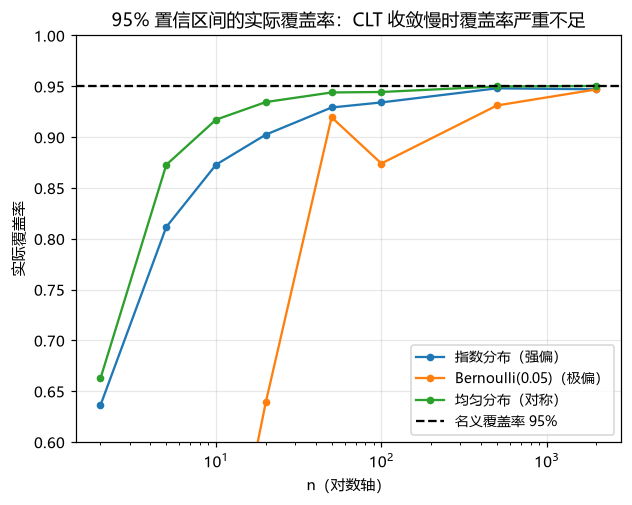

要点：
  均匀分布（对称、偏度 0）：n=5 覆盖率就接近 95%；
  指数分布（偏度 2）      ：n≈100 才稳定到 95%；
  Bernoulli(0.05)（偏度≈4.1）：n≈500 才稳定。
  → 偏度越大，CLT 收敛越慢，置信区间越不可信。这与 Berry-Esseen 完全一致。


In [13]:
# ---- 应用 2：95% 置信区间的实际覆盖率如何随 n 变化 ----
def coverage(n_, dist='exp', reps=20000, conf=0.95):
    z = ND.inv_cdf(1 - (1 - conf) / 2)          # 1.95996
    if dist == 'exp':
        gen, mu, sig = lambda: rng.exponential(1.0, (reps, n_)), 1.0, 1.0
    elif dist == 'bern':
        p = 0.05
        gen, mu, sig = lambda: (rng.random((reps, n_)) < p).astype(float), p, np.sqrt(p * (1 - p))
    elif dist == 'unif':
        gen, mu, sig = lambda: rng.random((reps, n_)), 0.5, 1 / np.sqrt(12)

    s = gen()
    xbar, sstd = s.mean(axis=1), s.std(axis=1, ddof=1)
    half = z * sstd / np.sqrt(n_)                # 用样本标准差替代 sigma（Slutsky）
    return np.mean(np.abs(xbar - mu) <= half)

ns_cov = [2, 5, 10, 20, 50, 100, 500, 2000]
for dist, label in [('exp', '指数分布（强偏）'), ('bern', 'Bernoulli(0.05)（极偏）'),
                    ('unif', '均匀分布（对称）')]:
    covs = [coverage(n_, dist) for n_ in ns_cov]
    plt.semilogx(ns_cov, covs, 'o-', ms=4, label=label)

plt.axhline(0.95, color='k', ls='--', lw=1.5, label='名义覆盖率 95%')
plt.xlabel('n（对数轴）'); plt.ylabel('实际覆盖率')
plt.title('95% 置信区间的实际覆盖率：CLT 收敛慢时覆盖率严重不足')
plt.ylim(0.6, 1.0); plt.legend(fontsize=9); plt.show()

print('要点：')
print('  均匀分布（对称、偏度 0）：n=5 覆盖率就接近 95%；')
print('  指数分布（偏度 2）      ：n≈100 才稳定到 95%；')
print('  Bernoulli(0.05)（偏度≈4.1）：n≈500 才稳定。')
print('  → 偏度越大，CLT 收敛越慢，置信区间越不可信。这与 Berry-Esseen 完全一致。')

---
# 第 3 章　两条定理其实是一体两面

## 3.1 统一视角：一个等式，两个推论

回顾那个唯一的关键事实：

$$\operatorname{Var}(\bar X_n)=\frac{\sigma^2}{n}$$

**把它写成两种形式，就得到两条定理：**

$$\underbrace{\bar X_n-\mu}_{\text{绝对误差}}\quad\text{和}\quad\underbrace{\sqrt n(\bar X_n-\mu)}_{\text{标准化误差}}$$

| 看哪个量 | 尺度 | 极限 | 得到 |
|---|---|---|---|
| $\bar X_n-\mu$ | $n^0$ | $0$ | **LLN** |
| $\sqrt n(\bar X_n-\mu)$ | $n^{1/2}$ | $N(0,\sigma^2)$ | **CLT** |

用方差表述更清楚：

$$\operatorname{Var}(\bar X_n-\mu)=\frac{\sigma^2}{n}\xrightarrow{n\to\infty}0
\qquad\Longrightarrow\qquad \text{LLN}$$

$$\operatorname{Var}\big(\sqrt n(\bar X_n-\mu)\big)=n\cdot\frac{\sigma^2}{n}=\sigma^2\ \ (\text{与 }n\text{ 无关})
\qquad\Longrightarrow\qquad \text{CLT}$$

> **核心洞察**：CLT 之所以是「二阶」定理，是因为它乘上了恰好能抵消 $1/n$ 方差衰减的那个 $\sqrt n$。
> 放大倍数选得太大或太小，得到的都是退化结论（见 2.4 节解释 4 的表格）。

## 3.2 逻辑关系：谁更强？谁蕴含谁？

这是一个常见的困惑点。答案是：**在方差有限的条件下，CLT 蕴含 LLN；但两条定理各有独立价值。**

### CLT ⟹ LLN（在 $\sigma^2<\infty$ 时）

若 $\sqrt n(\bar X_n-\mu)/\sigma\xrightarrow{d}N(0,1)$，即对任意 $M$，

$$P\left(\left|\frac{\sqrt n(\bar X_n-\mu)}{\sigma}\right|\le M\right)\to P(|N(0,1)|\le M)$$

取 $M=\varepsilon\sqrt n/\sigma$（随 $n$ 增大）：

$$P\big(|\bar X_n-\mu|\le\varepsilon\big)\to P(|N(0,1)|\le \infty)=1$$

即 $\bar X_n\xrightarrow{P}\mu$。**所以有了 CLT 就有了 WLLN**（这也是为什么 2.5 节的图里正态近似几乎与精确值重合）。

### 但 LLN 有 CLT 覆盖不到的领域

| 场景 | LLN 是否成立 | CLT 是否成立 |
|---|---|---|
| i.i.d.，$\mathbb E\lvert X\rvert<\infty$，$\sigma^2=\infty$（如 $t_2$ 分布） | ✅ 成立 | ❌ 不成立 |
| i.i.d.，$\mathbb E\lvert X\rvert=\infty$（柯西） | ❌ 不成立 | ❌ 不成立 |
| 弱相关平稳序列（遍历定理） | ✅ 成立 | 需要额外条件 |
| 非平稳但满足 Lindeberg | ✅ 成立 | ✅ 成立 |

**结论**：LLN 的条件严格弱于 CLT。CLT 需要二阶矩（甚至三阶矩来控制误差），LLN 只要一阶矩。当方差不存在时（$t_2$、Pareto $\alpha<2$），**你仍可以用样本均值估计期望，但不能用正态分布构造置信区间**。这是实践中极其重要的区别。

### 一个 $t_2$ 分布的例子（方差无穷但均值存在）

$t_2$ 分布的密度 $f(x)\propto(1+x^2/2)^{-3/2}$，尾部 $\sim x^{-3}$，所以 $\mathbb E|X|<\infty$ 但 $\mathbb E[X^2]=\infty$。

- LLN：$\bar X_n\xrightarrow{P}0$（**成立**）
- CLT：不存在常数 $a_n$ 使 $a_n\bar X_n\xrightarrow{d}N(0,1)$（**不成立**，极限是稳定分布）

下面的代码会把这个差别画出来。

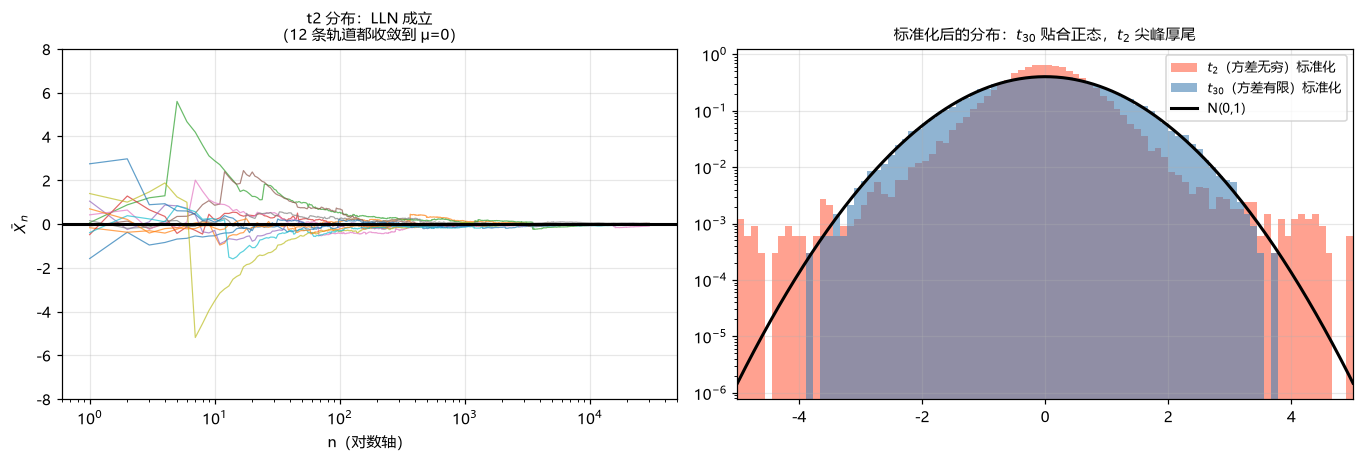

结论：
  t₂ 的均值存在 → 轨道仍收敛（LLN 成立），
  但标准化后分布是"尖峰厚尾"（其实是稳定分布），永远不收敛到正态（CLT 不成立）。
  实践含义：方差无穷时，样本均值可用，但正态置信区间不可用。


In [14]:
# ---- 对比：方差有限（CLT 成立）vs 方差无穷（只有 LLN 成立）----
# 用 t 分布：df 越小尾部越厚。df=2 → 方差无穷；df=30 → 近似正态
N_, K_ = 30000, 12
idx_ = np.arange(1, N_ + 1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

# 左图：轨道（都收敛到 0，因为均值存在）
for k in range(K_):
    axes[0].plot(idx_, np.cumsum(rng.standard_t(2, N_)) / idx_, lw=0.8, alpha=0.7)
axes[0].axhline(0, color='k', lw=2)
axes[0].set_xscale('log'); axes[0].set_ylim(-8, 8)
axes[0].set_title('t2 分布：LLN 成立\n（12 条轨道都收敛到 μ=0）', fontsize=10)
axes[0].set_xlabel('n（对数轴）'); axes[0].set_ylabel(r'$\bar X_n$')

# 右图：标准化后的分布（t2 不收敛到正态，t30 收敛）
n_s, reps_s = 500, 30000
xs3 = np.linspace(-5, 5, 300)
phi3 = np.array([ND.pdf(x) for x in xs3])

z2 = rng.standard_t(2, (reps_s, n_s)).mean(axis=1)
z2 = z2 / z2.std()                      # 用实测尺度标准化（因为理论 σ 无穷）
z30 = rng.standard_t(30, (reps_s, n_s)).mean(axis=1)
z30 = z30 / z30.std()

axes[1].hist(z2, bins=90, range=(-5, 5), density=True, color='tomato',
             alpha=0.6, label=r'$t_2$（方差无穷）标准化')
axes[1].hist(z30, bins=90, range=(-5, 5), density=True, color='steelblue',
             alpha=0.6, label=r'$t_{30}$（方差有限）标准化')
axes[1].plot(xs3, phi3, 'k-', lw=2, label='N(0,1)')
axes[1].set_xlim(-5, 5); axes[1].set_yscale('log')
axes[1].set_title('标准化后的分布：$t_{30}$ 贴合正态，$t_2$ 尖峰厚尾', fontsize=10)
axes[1].legend(fontsize=8.5)

plt.tight_layout(); plt.show()

print('结论：')
print('  t₂ 的均值存在 → 轨道仍收敛（LLN 成立），')
print('  但标准化后分布是"尖峰厚尾"（其实是稳定分布），永远不收敛到正态（CLT 不成立）。')
print('  实践含义：方差无穷时，样本均值可用，但正态置信区间不可用。')

---
# 第 4 章　为什么深度学习离不开这两条定理

前 3 章是数学。这一章回答：**在训练一个神经网络时，这两条定理在哪里起作用？**

一句话回答：**LLN 是「训练会收敛」的理由，CLT 是「收敛有多稳、需要多少样本」的理由。**

## 4.1 蒙特卡洛估计：LLN 给正确性，CLT 给误差条

深度学习里几乎所有「期望」都是靠采样近似的。设我们想算

$$I=\mathbb E_{x\sim p}[f(x)]=\int f(x)p(x)\,dx$$

用 i.i.d. 样本 $x_1,\dots,x_n\sim p$ 构造估计量

$$\hat I_n=\frac1n\sum_{i=1}^n f(x_i)$$

**LLN 告诉我们 $\hat I_n\xrightarrow{P}I$** —— 这就是「采样估计是无偏一致的」。但光有这个不够，我们还需要知道误差。

**CLT 告诉我们**（设 $\operatorname{Var}(f(x))=\sigma_f^2<\infty$）：

$$\sqrt n\,(\hat I_n-I)\xrightarrow{d}N(0,\sigma_f^2)
\qquad\Longrightarrow\qquad
\hat I_n\approx N\!\left(I,\ \frac{\sigma_f^2}{n}\right)$$

于是得到**蒙特卡洛误差条**：

$$\hat I_n\pm1.96\frac{\hat\sigma_f}{\sqrt n}\qquad\text{（95\% 置信区间）}$$

### 三个必须记住的推论

1. **蒙特卡洛误差与维度无关**。这是它相对网格法（误差 $\sim n^{-1/d}$）的压倒性优势，也是 MCMC、变分推断、重要性采样能用于高维问题的根本原因。
2. **误差是 $O(n^{-1/2})$，想要精度提高 10 倍需要 100 倍样本**。这是所有采样方法的固有诅咒。
3. **降低方差比增加样本更划算**。因为 $\hat I$ 的方差里 $\sigma_f^2$ 是可以设计的：
   - **控制变量法（control variates）**：$\hat I_{CV}=\frac1n\sum[f(x_i)-c(g(x_i)-\mathbb E g)]$，选 $g$ 与 $f$ 相关，可大幅削减 $\sigma_f^2$；
   - **重要性采样（importance sampling）**：从 $q$ 采样加权重，让 $f(x)p(x)/q(x)$ 的方差更小；
   - **Rao–Blackwell 化**：用条件期望替代随机量，方差单调不增。

> **反向思考**：如果你发现自己需要把样本量翻 100 倍才能让损失下降一点点，那大概率不是样本不够，而是**方差没降下来**。

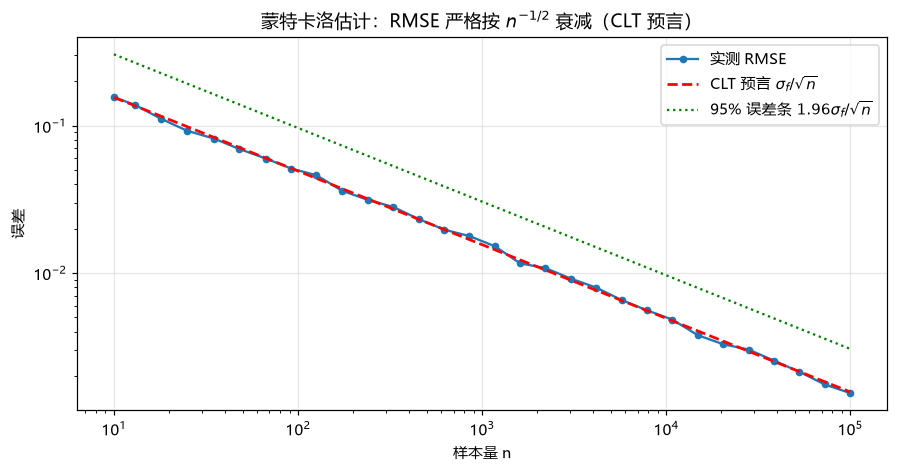

真值 I = e-1 = 1.718282
n=100  时 RMSE = 0.046085
n=10000 时 RMSE = 0.004817
样本量 ×100 → 误差降为 1/10，实测比值 = 9.57
偏置 max|bias| = 5.24e-03（无偏估计，偏差只是有限样本噪声）


In [15]:
# ---- 4.1 蒙特卡洛估计：误差条与 1/sqrt(n) 律 ----
# 目标：估计 I = E[exp(X)]，X ~ U(0,1)（真值 = e - 1）
true_I = np.e - 1
ns_mc = np.unique(np.logspace(1, 5, 30).astype(int))
reps_mc = 400

est = np.zeros((reps_mc, len(ns_mc)))
for j, n_ in enumerate(ns_mc):
    est[:, j] = np.exp(rng.random((reps_mc, n_))).mean(axis=1)

bias = est.mean(axis=0) - true_I
rmse = np.sqrt(((est - true_I) ** 2).mean(axis=0))
std_f = np.std(np.exp(rng.random(200000)))     # sigma_f
theory_rmse = std_f / np.sqrt(ns_mc)

plt.figure(figsize=(9.5, 4.4))
plt.loglog(ns_mc, rmse, 'o-', ms=4, label='实测 RMSE')
plt.loglog(ns_mc, theory_rmse, 'r--', lw=1.8, label=r'CLT 预言 $\sigma_f/\sqrt{n}$')
plt.loglog(ns_mc, 1.96 * std_f / np.sqrt(ns_mc), 'g:', lw=1.5,
           label=r'95% 误差条 $1.96\sigma_f/\sqrt{n}$')
plt.xlabel('样本量 n'); plt.ylabel('误差')
plt.title('蒙特卡洛估计：RMSE 严格按 $n^{-1/2}$ 衰减（CLT 预言）')
plt.legend(); plt.show()

print(f'真值 I = e-1 = {true_I:.6f}')
print(f'n=100  时 RMSE = {rmse[np.searchsorted(ns_mc,100)]:.6f}')
print(f'n=10000 时 RMSE = {rmse[np.searchsorted(ns_mc,10000)]:.6f}')
print(f'样本量 ×100 → 误差降为 1/10，实测比值 = '
      f'{rmse[np.searchsorted(ns_mc,100)]/rmse[np.searchsorted(ns_mc,10000)]:.2f}')
print(f'偏置 max|bias| = {np.abs(bias).max():.2e}（无偏估计，偏差只是有限样本噪声）')

## 4.2 SGD 的梯度噪声：一个活生生的 CLT

这是 CLT 在深度学习中最直接、最重要的应用。

设训练集有 $N$ 个样本，全批量梯度为

$$g=\frac1N\sum_{i=1}^N\nabla_\theta\ell(x_i;\theta)=\mathbb E_{i\sim\mathrm{Unif}(1..N)}\big[\nabla_\theta\ell(x_i;\theta)\big]$$

小批量（mini-batch）梯度取 $\mathcal B$ 个随机样本：

$$\hat g_{\mathcal B}=\frac1{|\mathcal B|}\sum_{i\in\mathcal B}\nabla_\theta\ell(x_i;\theta)$$

**这正是「样本均值」！** 而且是从有限总体中无放回抽样。于是：

- **LLN**：$\hat g_{\mathcal B}\to g$ 当 $|\mathcal B|\to\infty$（这就是为什么大批量梯度更准）；
- **CLT**：$\hat g_{\mathcal B}$ 近似服从正态分布。

$$\hat g_{\mathcal B}\ \approx\ N\!\left(g,\ \frac{\Sigma}{|\mathcal B|}\right),\qquad
\Sigma=\operatorname{Cov}\big(\nabla_\theta\ell(x_i;\theta)\big)$$

**注意 $\Sigma$ 是参数空间上的协方差矩阵** —— 一个 $d\times d$ 矩阵（$d$ 可达数十亿）。这就是 2.6 节**多维 CLT** 的直接应用。

### 由此得到的四条工程结论

**结论 1：梯度噪声标准差 $\propto 1/\sqrt{|\mathcal B|}$**

$$\mathrm{Std}(\hat g_{\mathcal B})=\frac{\sqrt{\operatorname{diag}(\Sigma)}}{\sqrt{|\mathcal B|}}$$

所以**批量大小 ×4 → 梯度噪声减半**。这与「学习率随批量增大而线性放大」的线性缩放法则（linear scaling rule）直接相关：若批量 ×4 使噪声减半，为了让参数更新幅度不变，学习率应 ×2，但实践中常用 ×4（因为还叠加了更新次数减少的影响）。

**结论 2：SGD 的轨迹可以用 SDE 描述**

把 $\hat g_{\mathcal B}=g+\text{噪声}$ 代入更新式，令 $\eta\to0$、$|\mathcal B|$ 固定，可得随机微分方程（SDE）：

$$d\theta_t=-g(\theta_t)\,dt+\sqrt{\frac{\eta}{|\mathcal B|}\Sigma}\,dW_t$$

- 漂移项 $-g\,dt$：梯度下降；
- 扩散项 $\sqrt{\eta\Sigma/|\mathcal B|}\,dW_t$：梯度噪声。

**这解释了 SGD 的核心行为**：噪声强度由 $\eta/|\mathcal B|$ 控制。噪声让 SGD 逃离尖锐极小值，倾向于收敛到**平坦极小值** —— 这就是 SGD 泛化优于全批量梯度下降的机制性解释。

**结论 3：梯度噪声的「温度」= 学习率 / 批量大小**

$$\text{有效温度}\ \propto\ \frac{\eta}{|\mathcal B|}$$

- 增大 $\eta$ 或减小 $|\mathcal B|$ → 温度升高 → 探索更强、更平坦的解；
- 减小 $\eta$ 或增大 $|\mathcal B|$ → 温度降低 → 收敛更精确。

**这条规律解释了两个实践现象**：
- 大批量训练容易收敛到尖锐解、泛化变差（温度太低，被"冻"在最近的极小值）；
- 训练后期需要学习率衰减（降温退火），让 SGD 稳定下来。

**结论 4：为什么大批量训练的「临界批量大小」存在**

当 $|\mathcal B|$ 超过某个临界值（critical batch size）后，继续增大批量几乎不再改善优化速度。原因：此时梯度噪声已小到不主导，**优化变成确定性问题，瓶颈从统计误差转为曲率**。这与 CLT 的 $1/\sqrt{|\mathcal B|}$ 衰减是一致的 —— 收益递减。

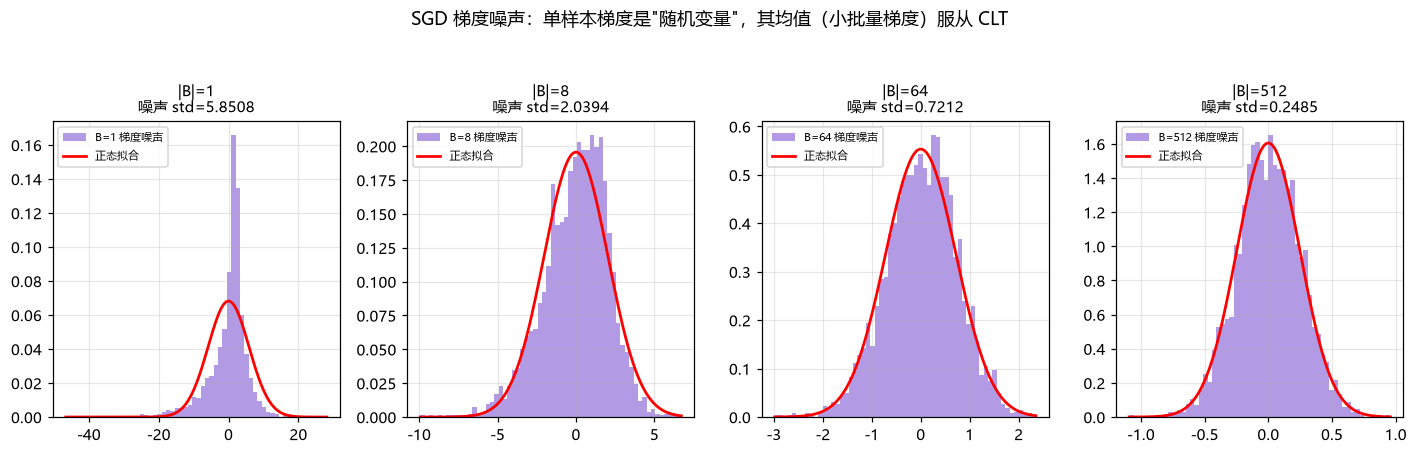

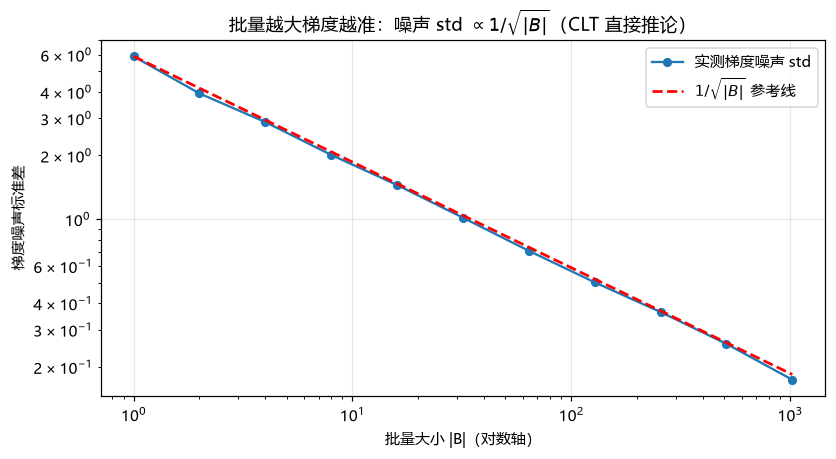

工程含义：
  批量 ×4 → 梯度噪声减半；批量 ×100 → 噪声降为 1/10。
  这条 1/sqrt(B) 律是"线性缩放法则"和"梯度累积"技巧的理论基础。


In [16]:
# ---- 4.2 实验：小批量梯度就是"样本均值"，噪声 ~ N(0, Sigma/B) ----
# 构造一个可控的回归问题，观察真实梯度分布
d_dim, N_data = 20, 20000
X_data = rng.standard_normal((N_data, d_dim))
w_true = rng.standard_normal(d_dim)
y_data = X_data @ w_true + 0.5 * rng.standard_normal(N_data)

theta = rng.standard_normal(d_dim) * 0.3      # 当前参数（故意偏离真值）

# 单个样本的梯度: grad = (x^T theta - y) * x
def per_sample_grads(idx):
    x, y = X_data[idx], y_data[idx]
    r = x @ theta - y
    return r[:, None] * x

g_full = per_sample_grads(np.arange(N_data)).mean(axis=0)   # 全批量梯度（真值）

plt.figure(figsize=(13, 3.9))
for i, B in enumerate([1, 8, 64, 512]):
    gs = np.array([per_sample_grads(rng.integers(0, N_data, B)).mean(axis=0)
                   for _ in range(3000)])
    # 取梯度的一个分量看分布
    comp = 0
    gs_c = gs[:, comp] - g_full[comp]

    ax = plt.subplot(1, 4, i + 1)
    ax.hist(gs_c, bins=60, density=True, color='mediumpurple', alpha=0.7,
            label=f'B={B} 梯度噪声')
    sd_emp = gs_c.std()
    xs_g = np.linspace(gs_c.min(), gs_c.max(), 200)
    ax.plot(xs_g, [ND.pdf(x / sd_emp) / sd_emp for x in xs_g], 'r-', lw=1.8,
            label='正态拟合')
    ax.set_title(f'|B|={B}\n噪声 std={sd_emp:.4f}', fontsize=9.5)
    ax.legend(fontsize=7.5)

plt.suptitle('SGD 梯度噪声：单样本梯度是"随机变量"，其均值（小批量梯度）服从 CLT', y=1.05)
plt.tight_layout(); plt.show()

# 验证 std ∝ 1/sqrt(B)
Bs = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
stds = []
for B in Bs:
    gs = np.array([per_sample_grads(rng.integers(0, N_data, B)).mean(axis=0)[0]
                   for _ in range(2000)])
    stds.append(gs.std())
stds = np.array(stds)

plt.figure(figsize=(8.5, 4.2))
plt.loglog(Bs, stds, 'o-', ms=5, label='实测梯度噪声 std')
plt.loglog(Bs, stds[0] / np.sqrt(np.array(Bs)), 'r--', lw=1.8,
           label=r'$1/\sqrt{|B|}$ 参考线')
plt.xlabel('批量大小 |B|（对数轴）'); plt.ylabel('梯度噪声标准差')
plt.title(r'批量越大梯度越准：噪声 std $\propto 1/\sqrt{|B|}$（CLT 直接推论）')
plt.legend(); plt.show()

print('工程含义：')
print('  批量 ×4 → 梯度噪声减半；批量 ×100 → 噪声降为 1/10。')
print('  这条 1/sqrt(B) 律是"线性缩放法则"和"梯度累积"技巧的理论基础。')

## 4.3 参数初始化：LLN/CLT 在「方差传播」中的直接应用

神经网络的初始化方案（Xavier、He）看起来是经验公式，其实**完全是从方差可加性 + CLT 推出来的**。

### 设定

考虑一层全连接：

$$z_j^{(l)}=\sum_{i=1}^{n_{l-1}}W_{ji}^{(l)}a_i^{(l-1)},\qquad a_j^{(l)}=\phi\big(z_j^{(l)}\big)$$

假设：

1. 权重 $W_{ji}$ i.i.d.，$\mathbb E[W]=0$，$\operatorname{Var}(W)=\sigma_w^2$；
2. 输入 $a_i^{(l-1)}$ i.i.d.，$\mathbb E[a]=0$，$\operatorname{Var}(a)=\sigma_a^2$；
3. $W$ 与 $a$ 独立。

### 推导：为什么需要 $\sigma_w^2 n_{l-1}=1$

由期望线性性和方差可加性：

$$\mathbb E[z_j]=0,\qquad
\operatorname{Var}(z_j)=\sum_{i=1}^{n_{l-1}}\operatorname{Var}(W_{ji}a_i)=n_{l-1}\sigma_w^2\sigma_a^2$$

**关键一步**：由 **CLT**，当 $n_{l-1}$ 较大时

$$z_j\ \approx\ N\!\left(0,\ n_{l-1}\sigma_w^2\sigma_a^2\right)$$

要保证信号在层间**不爆炸也不消失**，需要 $\operatorname{Var}(z_j)=\sigma_a^2$，即

$$\boxed{\ \sigma_w^2=\frac{1}{n_{l-1}}\ }$$

### 加激活函数后：Xavier 与 He 的分歧

对于**线性区域**的激活，$a=\phi(z)$ 的方差是 $z$ 的方差乘以一个系数：

$$\operatorname{Var}(a)=\mathbb E[\phi(z)^2]-\mathbb E[\phi(z)]^2$$

**Xavier 初始化（Glorot，2010）**：假设 $\phi$ 是 $\tanh$ 或 sigmoid，在 0 附近近似**线性**（$\phi(z)\approx z$），于是 $\operatorname{Var}(a)\approx\operatorname{Var}(z)$，条件变成

$$\sigma_w^2=\frac{1}{n_{l-1}}\quad\text{（前向）}\qquad\text{和}\qquad \sigma_w^2=\frac{1}{n_{l}}\quad\text{（反向）}$$

取折中（调和平均），得到

$$\sigma_w^2=\frac{2}{n_{l-1}+n_l}
\qquad\Longrightarrow\qquad
W\sim U\left[-\sqrt{\frac{6}{n_{l-1}+n_l}},\ \sqrt{\frac{6}{n_{l-1}+n_l}}\right]$$

**He 初始化（2015）**：假设 $\phi=\mathrm{ReLU}$，则 $a=\max(z,0)$，而 $z\sim N(0,\sigma_z^2)$ 时

$$\mathbb E[a^2]=\int_0^\infty z^2\frac{1}{\sqrt{2\pi}\sigma_z}e^{-z^2/2\sigma_z^2}dz=\frac{\sigma_z^2}{2},\qquad \mathbb E[a]=\frac{\sigma_z}{\sqrt{2\pi}}$$

所以 $\operatorname{Var}(a)=\frac{\sigma_z^2}{2}-\frac{\sigma_z^2}{2\pi}\approx\frac{\sigma_z^2}{2}$。**ReLU 把方差砍了一半**，所以需要把权重方差加倍：

$$\boxed{\ \sigma_w^2=\frac{2}{n_{l-1}}\ }
\qquad\Longrightarrow\qquad
W\sim N\!\left(0,\ \frac{2}{n_{l-1}}\right)$$

> **理解要点**：Xavier 和 He 的区别**不是**「一个更好一个更差」，而是**激活函数不同导致的方差因子不同**。
> - $\tanh$/sigmoid 的线性区方差因子 $\approx1$ → 用 $2/(n_{in}+n_{out})$；
> - ReLU 的方差因子 $\approx1/2$ → 用 $2/n_{in}$。
>
> **如果换成 GELU 或 SiLU，正确的做法是数值估计这个因子，而不是套公式。**

### 另一层：为什么深层网络的预激活趋于正态？

上面的推导用 CLT 得到了 $z_j$ 近似正态。这个结论有一个漂亮的**自我强化**性质：

1. 第 $l$ 层预激活 $z^{(l)}$ 近似正态（CLT）；
2. 若权重也初始化得好，$a^{(l)}=\phi(z^{(l)})$ 是正态的逐点非线性变换，仍然 i.i.d.；
3. 第 $l+1$ 层的 $z^{(l+1)}$ 又是大量 i.i.d. 项之和 → 由 CLT **再次**近似正态。

**所以「深层网络的预激活近似正态」是 CLT 在深度方向上的迭代应用。** 这也解释了：

- 为什么权重初始化要控制方差（否则正态假设在几层内就被破坏）；
- 为什么 BatchNorm / LayerNorm 有效（它们强制维持均值和方差，让 CLT 的"再正态化"持续成立）；
- 为什么均值场理论（mean-field theory）能把深层网络看作高斯过程（Neural Network Gaussian Process, NNGP）。

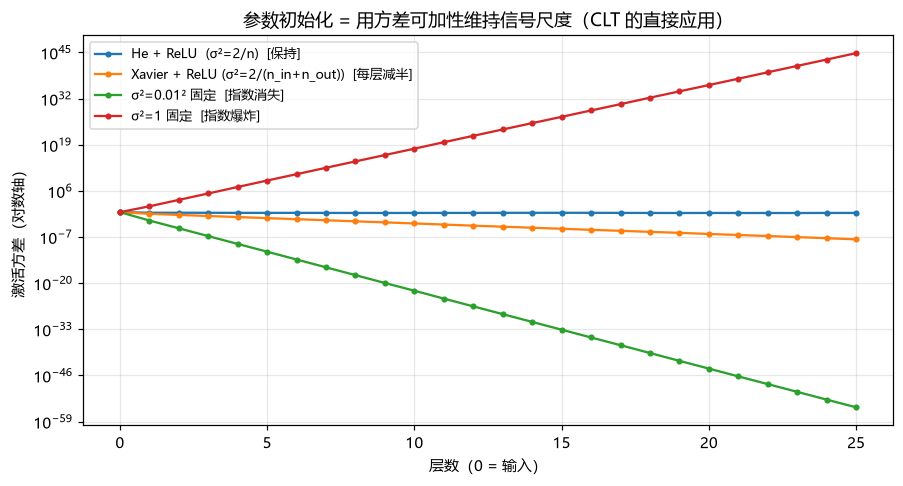

读数：
  He 初始化：方差在 25 层内基本保持水平 → 信号不爆炸不消失；
  Xavier+ReLU：每层减半 → 25 层后方差降到 2^-25 ≈ 3e-8，梯度消失；
  固定小方差：指数衰减，网络前几层就死了；
  固定大方差：指数爆炸。


In [17]:
# ---- 4.3 实验：不同初始化下的激活方差随深度的演化 ----
def forward_variance(depth, width, init, act, reps=40):
    # 返回每一层激活的方差（沿深度）
    vars_hist = []
    for _ in range(reps):
        a = rng.standard_normal((600, width))
        vs = [a.var()]
        for _l in range(depth):
            if init == 'he':
                W = rng.standard_normal((width, width)) * np.sqrt(2.0 / width)
            elif init == 'xavier':
                lim = np.sqrt(6.0 / (2 * width))
                W = rng.uniform(-lim, lim, (width, width))
            elif init == 'naive_small':
                W = rng.standard_normal((width, width)) * 0.01
            elif init == 'naive_large':
                W = rng.standard_normal((width, width)) * 1.0
            z = a @ W
            if act == 'relu':
                a = np.maximum(z, 0)
            elif act == 'tanh':
                a = np.tanh(z)
            else:
                a = z
            vs.append(a.var())
        vars_hist.append(vs)
    return np.mean(vars_hist, axis=0)

width_, depth_ = 128, 25
plt.figure(figsize=(9.5, 4.6))
for init, act, label in [
    ('he', 'relu', 'He + ReLU  (σ²=2/n)  [保持]'),
    ('xavier', 'relu', 'Xavier + ReLU (σ²=2/(n_in+n_out))  [每层减半]'),
    ('naive_small', 'relu', 'σ²=0.01² 固定  [指数消失]'),
    ('naive_large', 'relu', 'σ²=1 固定  [指数爆炸]'),
]:
    v = forward_variance(depth_, width_, init, act)
    plt.semilogy(range(len(v)), v, 'o-', ms=3, label=label)

plt.xlabel('层数（0 = 输入）'); plt.ylabel('激活方差（对数轴）')
plt.title('参数初始化 = 用方差可加性维持信号尺度（CLT 的直接应用）')
plt.legend(fontsize=8.5); plt.show()

print('读数：')
print('  He 初始化：方差在 25 层内基本保持水平 → 信号不爆炸不消失；')
print('  Xavier+ReLU：每层减半 → 25 层后方差降到 2^-25 ≈ 3e-8，梯度消失；')
print('  固定小方差：指数衰减，网络前几层就死了；')
print('  固定大方差：指数爆炸。')

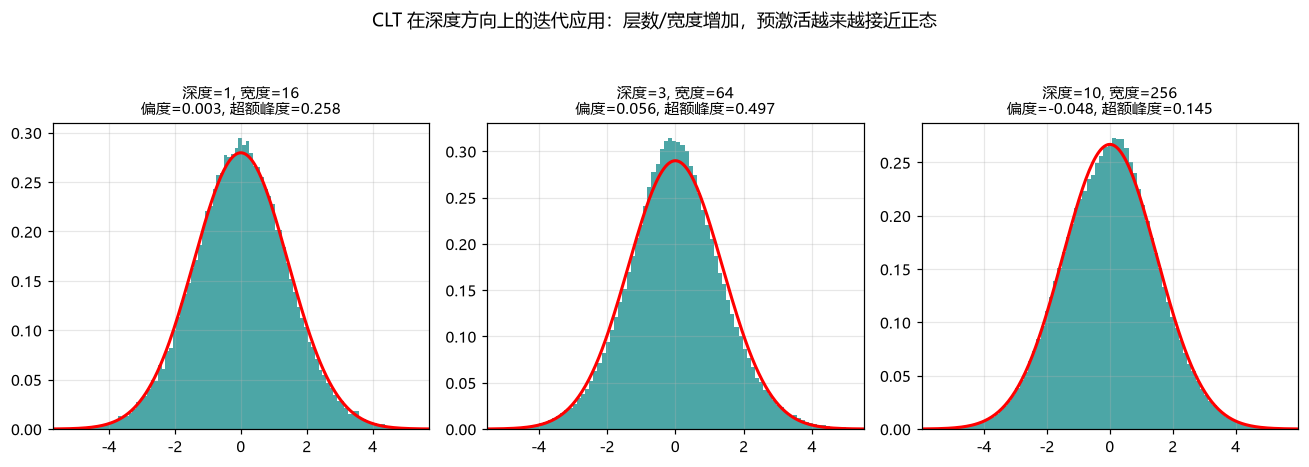

宽度越大（求和项越多）→ CLT 近似越好 → 偏度、峰度越接近 0。
这正是"深层网络 ≈ 高斯过程"（NNGP）这一理论的基础。


In [18]:
# ---- 4.3b 实验：深层网络的预激活到底有多"正态"？----
# 画最后一层预激活的直方图，叠加同方差的正态密度，并用偏度/峰度定量刻画
def preact_stats(depth, width, init='he', reps=3):
    # 累积 reps 次重复中最后一层预激活的样本，用于看分布形状
    zs_all = []
    for _ in range(reps):
        a = rng.standard_normal((1500, width))
        for l in range(depth):
            W = rng.standard_normal((width, width)) * np.sqrt(2.0 / width)
            z = a @ W
            if l == depth - 1:
                zs_all.append(z.ravel())
            a = np.maximum(z, 0)
    return np.concatenate(zs_all)

plt.figure(figsize=(12, 4))
for i, (depth, width) in enumerate([(1, 16), (3, 64), (10, 256)]):
    z = preact_stats(depth, width)
    ax = plt.subplot(1, 3, i + 1)
    ax.hist(z, bins=120, density=True, color='teal', alpha=0.7)
    s = z.std()
    xs_z = np.linspace(z.min(), z.max(), 300)
    ax.plot(xs_z, [ND.pdf(x / s) / s for x in xs_z], 'r-', lw=2)
    sk = np.mean(((z - z.mean()) / s) ** 3)
    ku = np.mean(((z - z.mean()) / s) ** 4) - 3
    ax.set_title(f'深度={depth}, 宽度={width}\n偏度={sk:.3f}, 超额峰度={ku:.3f}',
                 fontsize=9.5)
    ax.set_xlim(-4 * s, 4 * s)

plt.suptitle('CLT 在深度方向上的迭代应用：层数/宽度增加，预激活越来越接近正态', y=1.05)
plt.tight_layout(); plt.show()

print('宽度越大（求和项越多）→ CLT 近似越好 → 偏度、峰度越接近 0。')
print('这正是"深层网络 ≈ 高斯过程"（NNGP）这一理论的基础。')

# 第 5 章  常见误区与练习

前面四章把两个定理从直觉一路推到了深度学习里的应用。这一章做两件事：**先清掉最常见的错误理解**，再用一组练习检验自己是不是真的懂了。

## 5.1 十个常见误区

下面每一条都写清了「错在哪」和「正确的说法」，建议对照自己原来的理解逐条检查。

### 误区 1：大数定律保证样本均值「等于」期望
**错。** 它说的是**收敛**，不是相等。有限 $n$ 时 $\bar X_n-\mu$ 是随机变量，本身有分布（而且由 CLT，这个差大约是 $N(0,\sigma^2/n)$ 量级）。
正确的说法是：**任意给定精度 $\varepsilon>0$，$P(|\bar X_n-\mu|>\varepsilon)\to0$** —— 偏差可以任意小，但几乎不会恰好为 0。

### 误区 2：CLT 说「样本均值近似正态」
**说法不完整，容易误导。** $\bar X_n$ 本身会收敛到常数 $\mu$（一个退化分布），它**不是**近似正态。
真正近似正态的是**标准化**之后的量：
$$\frac{\bar X_n-\mu}{\sigma/\sqrt n}\ \xrightarrow{\ d\ }\ N(0,1)$$
等价地：$\bar X_n\approx N(\mu,\ \sigma^2/n)$ —— 正态中心在 $\mu$，而宽度以 $1/\sqrt n$ 收缩。少了「标准化」这一步，就会得到「$\bar X_n$ 趋向 $N(\mu,\sigma^2)$」这种错误结论（那样方差就不会随 $n$ 变小了，与 LLN 矛盾）。

### 误区 3：$n\ge30$ 就一定能用 CLT
**错，这是教科书里最有害的经验法则。** 收敛速度由 **Berry–Esseen** 的 $n^{-1/2}$ 控制，而常数取决于偏度：
$$\sup_x|P(Z_n\le x)-\Phi(x)|\ \le\ \frac{C\,\mathbb E|X-\mu|^3}{\sigma^3\sqrt n}$$
- 均匀分布、对称分布：$n=5$ 就很好；
- 指数分布（偏度 2）：$n=50$ 左右才像样；
- 对数正态、幂律：$n$ 要到几千；
- **柯西、$t_2$：任何 $n$ 都不行**（方差无穷，定理前提不满足）。

判断标准不是「$n$ 够不够 30」，而是「**偏度、尾部有多重，以及是否存在单一大项主导**」。

### 误区 4：LLN 和 CLT 是同一件事的两种说法
**错。** 它们回答的是**不同层级**的问题：
- LLN 管**一阶**：$\bar X_n\to\mu$，误差的**大小**（量级 $1/\sqrt n$）被它丢掉；
- CLT 管**二阶**：把这个误差**放大** $\sqrt n$ 倍后，看它剩下的**分布形状**。

LLN 说「会收敛」，CLT 说「收敛的过程中长什么样」。第 3 章已用 $t_2$ 例子说明：**可以 LLN 成立而 CLT 不成立**。

### 误区 5：CLT 要求随机变量同分布
**错，可以放松。** 只要满足 **Lindeberg–Feller 条件**（没有单一项主导总方差），独立但**不同分布**也成立，极限仍由总方差决定：
$$\frac{\sum_i(X_i-\mu_i)}{\sqrt{\sum_i\sigma_i^2}}\ \xrightarrow{\ d\ }\ N(0,1)$$
但**不能随意放松独立性**：强相关序列会破坏结论（例如 $X_i$ 全部相等时，$\bar X_n$ 恒等于 $X_1$，永不收敛）。

### 误区 6：方差无穷时 CLT 只是「收敛得慢一点」
**错。** 不是慢，而是**彻底不成立**。$t_2$ 的方差无穷，其均值被大离群值反复拉走；柯西分布（$\mathbb E|X|=\infty$）更极端：$\bar X_n$ **与 $X_1$ 同分布**，即样本均值分布是一个不动点，$n$ 再大也不会变窄。这类分布的极限要改用**稳定分布**（$\alpha<2$）来刻画，不是正态。

### 误区 7：独立性是 LLN 的必要条件
**错。** 对**弱**大数定律，一个常用的充分条件是**两两不相关**（即 $\operatorname{Cov}(X_i,X_j)=0$，比独立弱得多）—— 这正是切比雪夫证明的核心。
但要注意区分：**弱** LLN 不需要独立，**强** LLN（几乎必然收敛）通常需要更强的条件（如独立同分布 + 有限期望，或用 Borel–Cantelli 配合四阶矩/截断）。

### 误区 8：LLN 需要有限方差
**错。** 只需 $\mathbb E|X|<\infty$（Khinchin）。证明时用的是**截断法**：把 $X$ 截断成有界变量 $X^{(M)}$（有界必有方差），对截断部分用切比雪夫，再让 $M\to\infty$ 控制尾部。
但 **CLT 确实需要有限方差** $\sigma^2<\infty$ —— 这是两个定理在前提上最关键的差别。

### 误区 9：蒙特卡洛误差与维数有关
**对，但方向常常搞反。** 标准误是 $\sigma/\sqrt n$，**不显含维数 $d$**。这是蒙特卡洛相对网格法的核心优势（网格法误差 $\sim n^{-1/d}$，维数一高就废）。
代价藏在 $\sigma$ 里：高维目标函数的方差 $\sigma$ 往往很大，所以「不显含 $d$」不等于「高维免费」。

### 误区 10：批大小越大，SGD 就越接近「真梯度」
**方向对，但不能无限外推。**
- 由 CLT，$\hat g_{\mathcal B}\approx N\!\left(g,\ \frac{\Sigma}{|\mathcal B|}\right)$，梯度噪声的**标准差**按 $1/\sqrt{|\mathcal B|}$ 下降；
- 但真正影响参数的是**更新量** $\eta\hat g_{\mathcal B}$，其噪声标准差是 $\eta\sqrt{\Sigma/|\mathcal B|}$。若按线性缩放规则把 $|\mathcal B|$ 放大 $k$ 倍、同时把 $\eta$ 也放大 $k$ 倍，则噪声标准差变成
  $$k\cdot\frac{\sqrt{\Sigma}}{\sqrt{k|\mathcal B|}}=\sqrt{k}\cdot\frac{\sqrt{\Sigma}}{\sqrt{|\mathcal B|}}$$
  **不降反升**，而「信号 / 噪声」比 $|g|\big/\sqrt{\Sigma/|\mathcal B|}$ 只提高了 $\sqrt k$ 倍；
- 这正对应**临界批量大小** $B_{\mathrm{crit}}\approx \operatorname{tr}(\Sigma)/\|g\|^2$：当 $|\mathcal B|\gg B_{\mathrm{crit}}$ 时梯度已几乎确定，再加大批量只是**减少步数**，并不能加快收敛。

## 5.2 自测练习

先自己做，再看 5.3 的答案与数值验证。难度从「套公式」到「想清楚反例」递进。

### A 组：基本理解

**A1.** 判断对错并说明理由：
- (a) 只要 $n$ 足够大，$\bar X_n$ 就一定等于 $\mu$；
- (b) $n\to\infty$ 时 $\operatorname{Var}(\bar X_n)\to0$，所以 $\bar X_n$ 依概率收敛到 $\mu$（假设 $\sigma^2<\infty$）；
- (c) 若 $\bar X_n\xrightarrow{P}\mu$，则 $\bar X_n^2\xrightarrow{P}\mu^2$。

**A2.** 设 $X_i$ 独立同分布，$\mu=3$，$\sigma^2=4$。用切比雪夫不等式估计 $P(|\bar X_{100}-3|>0.5)$ 的上界。再用 CLT 估计这个概率的近似值，比较两者的差距。

**A3.** 要让标准误 $\sigma/\sqrt n$ 降到 $\sigma$ 的 $1\%$，需要多少样本？如果只要求降到 $10\%$ 呢？说明为什么「精度提高 10 倍」的代价是「样本量提高 100 倍」。

### B 组：条件与反例

**B1.** 下列情形中 CLT 是否适用？分别说明理由：
- (a) $X_i\sim U[0,1]$，$n=10$；
- (b) $X_i\sim \mathrm{Exp}(1)$，$n=5$；
- (c) $X_i$ 独立但方差不同，且其中一个方差占总方差 99%；
- (d) $X_i$ 服从 $t_2$，$n=10^6$。

**B2.** 构造一个反例：$X_1,X_2,\dots$ **独立、均值都是 $0$、方差存在但无界**，使得 $\bar X_n$ 不依概率收敛到 $0$。并说明切比雪夫不等式给出的界为什么会失效。
（注意：若方差**一致有界**，那么只要两两不相关，弱大数定律就成立 —— 所以反例的关键必须落在「方差无界」上。）

**B3.** 已知 $X_i$ 独立同分布，$\mathbb E|X_i|=\infty$（如柯西分布）。此时 $\bar X_n$ 还会收敛吗？如果不会，它的分布有什么特殊性质？

### C 组：应用与计算

**C1.** 二项分布的正态近似：$X\sim\mathrm{Bin}(1000,0.3)$，用 CLT 估计 $P(X\le 320)$。分别给出「不做连续性修正」和「做连续性修正」的结果，并说明哪个更准。

**C2.** 蒙特卡洛积分：用 $n$ 个样本估计 $\int_0^1 e^{x^2}dx$，单次样本的标准差约为多少？若想让误差条（$95\%$ 置信区间半宽）小于 $10^{-3}$，$n$ 大概要多少？

**C3.** SGD：设单个样本梯度方差为 $\Sigma$，批量大小 $|\mathcal B|=64$。若把批量增大到 $256$，梯度噪声的标准差下降多少倍？若同时按线性缩放把学习率放大 4 倍，参数更新的噪声水平变化了多少？这与「临界批量大小」有什么关系？

### D 组：动手实验

**D1.** 数值验证 Berry–Esseen：取 $X_i$ 为指数分布（偏度 2），画出 $n=2,5,20,100$ 时标准化样本均值的分布与标准正态的差异，并用 KS 统计量定量给出误差随 $n$ 的下降速度。它接近 $n^{-1/2}$ 吗？

**D2.** 用重对数律（LIL）的尺度检验「$\sqrt n$ 是临界速度」：分别画 $\bar X_n-\mu$ 乘以 $n^{0.4}$、$n^{0.5}$、$n^{0.6}$ 后的轨迹，观察哪一档刚好「振荡不发散」。

## 5.3 答案与数值验证

### A 组

**A1.**
- (a) **错。** LLN 说的是收敛：$\forall\varepsilon>0,\ P(|\bar X_n-\mu|>\varepsilon)\to0$。有限 $n$ 时 $\bar X_n$ 仍是随机变量，由 CLT 还有 $O(1/\sqrt n)$ 的随机波动，几乎不会恰好等于 $\mu$。
- (b) **对。** 这正是切比雪夫的路线：$P(|\bar X_n-\mu|>\varepsilon)\le \operatorname{Var}(\bar X_n)/\varepsilon^2=\dfrac{\sigma^2}{n\varepsilon^2}\to0$。前提是均值存在且**方差有限**。
- (c) **对。** 连续映射定理：$g(x)=x^2$ 连续，故 $\bar X_n\xrightarrow{P}\mu\Rightarrow \bar X_n^2\xrightarrow{P}\mu^2$。收敛模式在连续映射下保持不变。

**A2.** $\operatorname{Var}(\bar X_{100})=\sigma^2/n=4/100=0.04$，故
$$\text{切比雪夫：}\ P(|\bar X_{100}-3|>0.5)\le\frac{0.04}{0.5^2}=0.16$$
$$\text{CLT：}\ z=\frac{0.5}{2/\sqrt{100}}=2.5,\qquad P(|Z|>2.5)=2(1-\Phi(2.5))\approx 0.0124$$
切比雪夫的上界比真实值**大了十几倍**（$0.16$ vs $0.0124$）—— 它永远成立，但非常「松」。这也说明：**能用 CLT 时不要用切比雪夫估概率**，切比雪夫只适合用来证明极限。

**A3.** 精度要求 $\dfrac{\sigma}{\sqrt n}\le \frac{\sigma}{k}$，即 $\sqrt n\ge k$，故
- 降到 $1\%$：$\sqrt n=100\Rightarrow n=10^4$；
- 降到 $10\%$：$\sqrt n=10\Rightarrow n=100$。

精度提高 10 倍，样本量要提高 100 倍 —— 因为 $\text{精度}\propto 1/\sqrt n$ 是**平方关系**。这就是蒙特卡洛「收敛慢」的根源，也是它唯一的弱点（优点是不依赖维数）。

### B 组

**B1.**
- (a) **适用，且已经相当好。** $U[0,1]$ 有界、对称、偏度 $0$，Berry–Esseen 的界很小，$n=10$ 时误差通常已在 $1\%$ 量级。
- (b) **勉强，但明显不准。** $\mathrm{Exp}(1)$ 的偏度是 $2$，$n=5$ 时分布还明显右偏。经验上要 $n\approx 50$ 才「看起来像」正态。
- (c) **不适用（不满足 Lindeberg 条件）。** 一个分量占了总方差的 $99\%$，属于「单一大项主导」，此时和的分布基本就是那一项的分布，不会正态化。
- (d) **不适用，而且 $n=10^6$ 也救不了。** $t_2$ 的方差无穷，CLT 前提不成立。更本质的是**尺度变了**：此时 $\bar X_n$ 需要用带对数修正的尺度 $\sqrt{n\log n}$（而不是 $\sqrt n$）才能得到正态极限，用 $\sqrt n$ 规范化永远收敛不到 $N(0,1)$。

**B2.** 取 $X_i$ 独立，$P(X_i=a_i)=P(X_i=-a_i)=1/2$，其中 $a_i=i$。则 $\mathbb E[X_i]=0$，$\operatorname{Var}(X_i)=i^2$，于是
$$\operatorname{Var}(\bar X_n)=\frac{1}{n^2}\sum_{i=1}^n i^2=\frac{(n+1)(2n+1)}{6n}\sim\frac{n}{3}\ \longrightarrow\ \infty$$
方差发散，$\bar X_n$ 的波动量级是 $\sqrt{n}$ 而不是 $1/\sqrt n$，所以**不依概率收敛到 $0$**。
切比雪夫界 $\dfrac{\operatorname{Var}(\bar X_n)}{\varepsilon^2}\sim\dfrac{n}{3\varepsilon^2}\to\infty$ —— 界是「$\le\infty$」，**完全失效**。所以弱大数定律的切比雪夫证明里，「方差一致有界」这个条件是实质性的。

**B3.** **不收敛。** 柯西分布 $\mathbb E|X|=\infty$，连大数定律都不成立。用特征函数看最清楚：标准柯西的 $\varphi(t)=e^{-|t|}$，于是
$$\varphi_{\bar X_n}(t)=\left[e^{-|t|/n}\right]^n=e^{-|t|}$$
**与 $X_1$ 的特征函数完全相同** —— 也就是说 $\bar X_n$ 与 $X_1$ **同分布**，$n$ 再大分布都不变。柯西是「$1$-稳定分布」，它本身就是自己的极限（不动点），极限分布要用稳定分布族（指数 $\alpha<2$）而不是正态来描述。

### C 组

**C1.** $X\sim\mathrm{Bin}(1000,0.3)$：$\mu=np=300$，$\sigma=\sqrt{np(1-p)}=\sqrt{210}\approx14.49$。
- **不做连续性修正**（用 $320$）：$z=\dfrac{320-300}{14.49}=1.380$，$P\approx\Phi(1.380)=0.9162$；
- **做连续性修正**（用 $320.5$）：$z=\dfrac{320.5-300}{14.49}=1.415$，$P\approx\Phi(1.415)=0.9215$。

**修正版更准。** 原因是二项分布是**离散**的，而正态是**连续**的：$P(X\le 320)$ 对应的是区间 $(-\infty,320.5]$ 的面积（把每个整数点摊成一个宽度为 1 的小矩形）。离散分布在用连续分布近似时，边界往「半个格子」外扩，就是连续性修正。下面代码会给出精确值对照。

**C2.** 目标量 $\theta=\int_0^1 e^{x^2}dx\approx1.4627$。取 $U\sim U[0,1]$，估计量 $g(U)=e^{U^2}$，$\sigma_g=\sqrt{\operatorname{Var}(e^{U^2})}$。
由 CLT，误差 $\approx N(0,\sigma_g^2/n)$，$95\%$ 置信区间半宽为 $1.96\sigma_g/\sqrt n$。要求 $<10^{-3}$：
$$\sqrt n>\frac{1.96\,\sigma_g}{10^{-3}}\approx 1.96\times 10^3\,\sigma_g$$
代入 $\sigma_g$（数值见下）可得 $n$ 的量级在 $10^5\!\sim\!10^6$。**注意这个估计本身也用到了 CLT** —— 这正是 CLT 在深度学习里最常见、最实际的用途：给任何蒙特卡洛估计配一个误差条。

**C3.** 梯度噪声标准差 $\propto 1/\sqrt{|\mathcal B|}$：
- $|\mathcal B|:64\to256$（放大 $4$ 倍）$\Rightarrow$ 标准差下降 $\sqrt4=2$ 倍；
- 同时 $\eta$ 放大 $4$ 倍 $\Rightarrow$ 更新量噪声标准差变为原来的 $4/2=2$ 倍，**反而变大**；
- 而「信号/噪声」比只提高到 $\sqrt4=2$ 倍。

所以单纯堆批量（且按线性缩放调 $\eta$）并不能让优化「更精确」。当 $|\mathcal B|$ 超过**临界批量大小** $B_{\mathrm{crit}}\approx\operatorname{tr}(\Sigma)/\|g\|^2$ 后，梯度已接近确定，再加批量只会减少步数、不会加速收敛。下面代码用一维例子演示这个现象。

### D 组（提示，实验代码见下）

**D1.** 用 KS 统计量 $\sup_x|F_n(x)-\Phi(x)|$ 度量误差，对 $n$ 取对数坐标做回归，斜率应接近 $-0.5$，即误差 $\sim n^{-1/2}$ —— 这就是 Berry–Esseen 的速度，也是 CLT 收敛「不算快」的定量表达。

**D2.** 关键是先定出量级：$\bar X_n-\mu$ 本身是 $n^{-0.5}$ 量级，所以乘上 $n^{a}$ 之后量级变成 $n^{\,a-0.5}$。
- $a=0.4$：$n^{-0.1}\to0$，轨迹被**压平**；
- $a=0.5$：$n^{0}=O(1)$，轨迹保持**有限振荡** —— 这才是临界尺度；
- $a=0.6$：$n^{0.1}\to\infty$，轨迹**发散**。

即：$n^{0.4}$ 压得太狠、$n^{0.6}$ 放得太松，只有 $\sqrt n$ 恰好把偏差固定在 $O(1)$。这与 LIL 的结论一致 —— 上极限量级是 $\sqrt{n\log\log n}$，比 $\sqrt n$ 只多了一个极慢的对数因子。

In [19]:
# ---- 5.3 验证（一）：A2 / C1 / C2 / C3 / B2 的数值对照 ----
from math import comb, log, exp, sqrt

print('【A2】切比雪夫上界 vs CLT 近似 vs 模拟频率')
mu, sig, n_, eps = 3.0, 2.0, 100, 0.5
cheb = (sig ** 2 / n_) / eps ** 2
clt_p = 2 * (1 - ND.cdf(eps / (sig / sqrt(n_))))
sim = np.mean(np.abs(rng.normal(mu, sig, (50_000, n_)).mean(axis=1) - mu) > eps)
print(f'  切比雪夫上界 = {cheb:.4f}')
print(f'  CLT 近似     = {clt_p:.4f}')
print(f'  模拟频率     = {sim:.4f}')
print('  → 切比雪夫界永远有效但很松；CLT 与模拟吻合得很好。')

print()
print('【C1】二项分布的正态近似与连续性修正  (X ~ Bin(1000, 0.3))')
n_b, p_b, k0 = 1000, 0.3, 320
mu_b, sig_b = n_b * p_b, sqrt(n_b * p_b * (1 - p_b))
exact = sum(exp(log(comb(n_b, k)) + k * log(p_b) + (n_b - k) * log(1 - p_b))
            for k in range(k0 + 1))
no_cc = ND.cdf((k0 - mu_b) / sig_b)
with_cc = ND.cdf((k0 + 0.5 - mu_b) / sig_b)
print(f'  精确值        = {exact:.6f}')
print(f'  无修正        = {no_cc:.6f}   误差 {abs(no_cc - exact):.2e}')
print(f'  有修正        = {with_cc:.6f}   误差 {abs(with_cc - exact):.2e}')
print('  → 修正后误差小一个量级，说明"半个格子"确实不能省。')

print()
print('【C2】蒙特卡洛积分 ∫₀¹ e^(x²) dx 的样本量与误差条')
N = 2_000_000
g = np.exp(rng.random(N) ** 2)
theta_hat, sigma_g = g.mean(), g.std(ddof=1)
half = 1.96 * sigma_g / sqrt(N)
print(f'  估计值 = {theta_hat:.6f} ± {half:.2e}  (95%)')
print(f'  单样本标准差 σ_g = {sigma_g:.4f}')
for target in [1e-2, 1e-3, 1e-4]:
    need = int(np.ceil((1.96 * sigma_g / target) ** 2))
    print(f'  要让半宽 < {target:.0e}：n ≈ {need:,}')
print('  → 半宽 ∝ 1/√n：精度每提高 10 倍，样本量要涨 100 倍。')

print()
print('【C3】批量大小 + 线性缩放学习率 → 更新噪声反而变大')
Sigma, B0, eta0 = 1.0, 64, 0.1
for k in [1, 4, 16, 64]:
    B, eta = B0 * k, eta0 * k          # 线性缩放：η ∝ |B|
    sd_grad = sqrt(Sigma / B)
    print(f'  |B|={B:5d}, η={eta:6.2f} | 梯度噪声σ={sd_grad:.4f}, '
          f'更新噪声σ={eta * sd_grad:.4f}, 信噪比={1 / sd_grad:6.2f}')
print('  → 更新噪声 ∝ √k 增大；信噪比只提高 √k 倍，这就是临界批量大小的由来。')

print()
print('【B2】方差无界 ⇒ 弱大数定律失效（X_i = ±i，均值为 0）')
for n_v in [100, 400, 1600, 6400]:
    a = np.arange(1, n_v + 1, dtype=float)
    X = rng.choice([-1.0, 1.0], size=(2000, n_v)) * a
    xbar = X.mean(axis=1)
    print(f'  n={n_v:5d} | X̄_n 模拟标准差 = {xbar.std():7.3f} '
          f'(理论 √(n/3) = {sqrt(n_v / 3):7.3f}), P(|X̄_n|>1) = {np.mean(np.abs(xbar) > 1):.3f}')
print('  → 标准差随 n 增大而不收敛，X̄_n 始终在 O(√n) 量级游荡。')

【A2】切比雪夫上界 vs CLT 近似 vs 模拟频率
  切比雪夫上界 = 0.1600
  CLT 近似     = 0.0124
  模拟频率     = 0.0124
  → 切比雪夫界永远有效但很松；CLT 与模拟吻合得很好。

【C1】二项分布的正态近似与连续性修正  (X ~ Bin(1000, 0.3))
  精确值        = 0.920768
  无修正        = 0.916227   误差 4.54e-03
  有修正        = 0.921412   误差 6.44e-04
  → 修正后误差小一个量级，说明"半个格子"确实不能省。

【C2】蒙特卡洛积分 ∫₀¹ e^(x²) dx 的样本量与误差条
  估计值 = 1.462511 ± 6.57e-04  (95%)
  单样本标准差 σ_g = 0.4741
  要让半宽 < 1e-02：n ≈ 8,635
  要让半宽 < 1e-03：n ≈ 863,406
  要让半宽 < 1e-04：n ≈ 86,340,527
  → 半宽 ∝ 1/√n：精度每提高 10 倍，样本量要涨 100 倍。

【C3】批量大小 + 线性缩放学习率 → 更新噪声反而变大
  |B|=   64, η=  0.10 | 梯度噪声σ=0.1250, 更新噪声σ=0.0125, 信噪比=  8.00
  |B|=  256, η=  0.40 | 梯度噪声σ=0.0625, 更新噪声σ=0.0250, 信噪比= 16.00
  |B|= 1024, η=  1.60 | 梯度噪声σ=0.0312, 更新噪声σ=0.0500, 信噪比= 32.00
  |B|= 4096, η=  6.40 | 梯度噪声σ=0.0156, 更新噪声σ=0.1000, 信噪比= 64.00
  → 更新噪声 ∝ √k 增大；信噪比只提高 √k 倍，这就是临界批量大小的由来。

【B2】方差无界 ⇒ 弱大数定律失效（X_i = ±i，均值为 0）
  n=  100 | X̄_n 模拟标准差 =   5.922 (理论 √(n/3) =   5.774), P(|X̄_n|>1) = 0.867
  n=  400 | X̄_n 模拟标准差 =  11.524 (理论 √(n/3) =  11.547), P

  n= 6400 | X̄_n 模拟标准差 =  46.305 (理论 √(n/3) =  46.188), P(|X̄_n|>1) = 0.979
  → 标准差随 n 增大而不收敛，X̄_n 始终在 O(√n) 量级游荡。


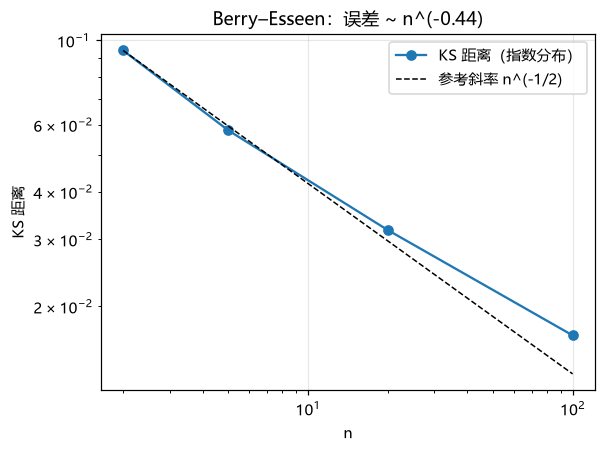

【D1】拟合斜率 = -0.437 （理论 -0.5）
  蒙特卡洛噪声地板 ≈ 1/√50000 = 0.0045，所以只用 n=2~100 做回归，避免撞到地板。


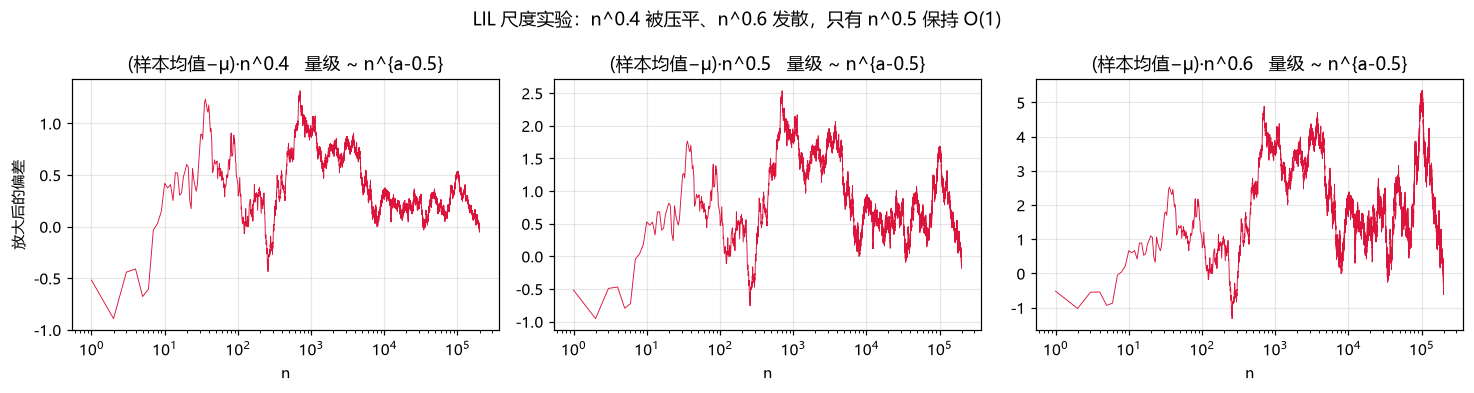

【D2】a=0.4 → 压向 0；a=0.5 → 有限振荡（临界）；a=0.6 → 发散。


In [20]:
# ---- 5.3 验证（二）：D1 Berry–Esseen 速率 + D2 LIL 临界尺度 ----
# D1：用 KS 统计量度量「标准化样本均值」与标准正态的距离，看它是否按 n^(-1/2) 下降
_grid = np.linspace(-10, 10, 200001)
_phi_grid = np.array([ND.cdf(x) for x in _grid])

def ks_to_normal(z):
    # z 已标准化（均值 0、方差 1）；返回经验 CDF 与 Φ 的最大距离
    zs = np.sort(z)
    m = zs.size
    Phi = np.interp(zs, _grid, _phi_grid)
    F = np.arange(1, m + 1) / m
    return max(np.max(np.abs(F - Phi)), np.max(np.abs(F - 1.0 / m - Phi)))

ns_d1, ks_vals, REPS = [2, 5, 20, 100], [], 50_000
for n_ in ns_d1:
    X = rng.exponential(1.0, (REPS, n_))      # Exp(1)：均值 1、方差 1、偏度 2
    z = (X.mean(axis=1) - 1.0) / (1.0 / np.sqrt(n_))
    ks_vals.append(ks_to_normal(z))

slope = np.polyfit(np.log(ns_d1), np.log(ks_vals), 1)[0]
plt.figure(figsize=(5.8, 4.2))
plt.loglog(ns_d1, ks_vals, 'o-', label='KS 距离（指数分布）')
plt.loglog(ns_d1, ks_vals[0] * np.sqrt(ns_d1[0] / np.array(ns_d1, float)),
           'k--', lw=1, label='参考斜率 n^(-1/2)')
plt.xlabel('n'); plt.ylabel('KS 距离')
plt.title(f'Berry–Esseen：误差 ~ n^({slope:.2f})')
plt.legend(); plt.show()
print('【D1】拟合斜率 =', round(slope, 3), '（理论 -0.5）')
print(f'  蒙特卡洛噪声地板 ≈ 1/√{REPS} = {1 / np.sqrt(REPS):.4f}，'
      '所以只用 n=2~100 做回归，避免撞到地板。')

# D2：LIL —— 只有 √n 是"临界尺度"
n_max = 200_000
S = np.cumsum(rng.standard_normal(n_max))
idx = np.arange(1, n_max + 1)
dev = S / idx                                  # X̄_n - 0，量级 n^(-0.5)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, a in zip(axes, [0.4, 0.5, 0.6]):
    ax.plot(idx, dev * idx ** a, lw=0.6, color='crimson')
    ax.set_xscale('log')
    ax.set_title(f'(样本均值−μ)·n^{a}   量级 ~ n^{{a-0.5}}')
    ax.set_xlabel('n')
axes[0].set_ylabel('放大后的偏差')
plt.suptitle('LIL 尺度实验：n^0.4 被压平、n^0.6 发散，只有 n^0.5 保持 O(1)')
plt.tight_layout(); plt.show()
print('【D2】a=0.4 → 压向 0；a=0.5 → 有限振荡（临界）；a=0.6 → 发散。')

## 5.4 全篇收束：一张表记住 LLN 与 CLT

把整份笔记压缩成下面这张对照表，剩下的细节都可以从这里反推回去。

| 维度 | 大数定律 LLN | 中心极限定理 CLT |
|---|---|---|
| 管什么 | 样本均值的**位置**（一阶） | 样本均值的**波动形状**（二阶） |
| 结论 | $\bar X_n\xrightarrow{P/a.s.}\mu$ | $\dfrac{\bar X_n-\mu}{\sigma/\sqrt n}\xrightarrow{d}N(0,1)$ |
| 误差量级 | $O(1)$ 且趋于 0（不刻画速度） | 精确给出 $O(n^{-1/2})$ 与常数 $\sigma$ |
| 核心前提 | $\mathbb E\lvert X\rvert<\infty$（WLLN 可再放宽到两两不相关 + 方差有界） | $\mathbb E X^2<\infty$ 且 i.i.d.（或满足 Lindeberg） |
| 极限对象 | 常数（退化分布） | 非退化随机变量（正态） |
| 证明工具 | 切比雪夫 + Borel–Cantelli；截断法 | 特征函数 + 泰勒展开 + Lévy 连续性 |
| 收敛速度 | 无定量结果（可由 CLT 反推） | Berry–Esseen：$Cn^{-1/2}$，常数由偏度决定 |
| 方差无穷时 | 可能仍成立（如 $t_2$、柯西，只要均值存在） | **彻底失效**（$t_2$、柯西） |
| 一句话 | 「平均下来就稳定了」 | 「稳定的同时还长得像正态」 |

### 三条主线回顾

1. **同一个 $\sigma^2/n$ 贯穿全篇。**
   $\operatorname{Var}(\bar X_n)=\sigma^2/n$ 是发动机：LLN 用它证明「云团塌缩成一个点」；CLT 把它乘回 $n$ 得到与 $n$ 无关的 $\sigma^2$，从而有稳定的极限分布。
2. **为什么偏偏是正态？**
   三种视角互相印证 —— 特征函数的**不动点** $2\psi(t/\sqrt2)=\psi(t)$、稳定分布族中**唯一有限方差**的成员、约束方差下的**最大熵**分布。再配上重对数律 $\sqrt{n\log\log n}$ 与 CLT 的 $\sqrt n$ 对照，可以看到 $\sqrt n$ 是一条精确的临界线。
3. **深度学习里到处都是它。**
   蒙特卡洛误差条 $1.96\sigma_f/\sqrt n$、SGD 梯度噪声 $\hat g_{\mathcal B}\approx N(g,\Sigma/|\mathcal B|)$ 与临界批量大小 $B_{\mathrm{crit}}\approx\operatorname{tr}(\Sigma)/\|g\|^2$、Xavier/He 初始化维持信号方差 —— 都是 $\sigma^2/n$ 律与 CLT 的直接后果。

### 延伸阅读

- Durrett, *Probability: Theory and Examples* —— 第 2 章（LLN）、第 3 章（CLT），最标准的严格处理。
- Billingsley, *Probability and Measure* —— 特征函数证明 CLT 的经典写法，Lindeberg–Feller 的完整条件。
- Williams, *Probability with Martingales* —— 用鞅收敛定理统一处理 SLLN，视角最漂亮。
- 费勒《概率论及其应用》第一卷 —— 棣莫弗–拉普拉斯定理的历史推导，连续性修正讲得最清楚。
- LeCun et al., *Efficient BackProp* (1998)；Glorot & Bengio (2010)；He et al. (2015) —— 初始化理论的原始文献。
- McCandlish et al., *An Empirical Model of Large-Batch Training* (2018) —— 临界批量大小 $B_{\mathrm{crit}}$ 的来源。

> **最后的建议**：遇到任何「求和 / 平均」的问题，先问两个问题 —— ① 均值存在吗（决定 LLN 能不能用）？② 方差有限吗（决定 CLT 能不能用）？这两问能挡掉绝大多数误用。